In [170]:
"""
Section 1: Importing n & k data for various materials and defining physical constants, wavelength ranges, etc.
"""


import numpy as np 
import matplotlib.pyplot as plt 
import scipy.integrate as integrate
from scipy.interpolate import PchipInterpolator
from scipy.integrate import simpson 
import os 

from __future__ import division, print_function, absolute_import

from numpy import cos, inf, zeros, array, exp, conj, nan, isnan, pi, sin, seterr
from numpy.lib.scimath import arcsin
import sys 

import torch #pytorch 


"Setting up lists to contain the information from the txt file or excel file" 
wl_array = []

n_W = []
k_W = []

n_Yb2O3 = []
k_Yb2O3 = []

n_MgO = []
k_MgO  = []

n_Y2O3 = []
k_Y2O3 = []

n_BeO = []
k_BeO = []

n_AlN = []
k_AlN = []

n_ZrO2 = []
k_ZrO2= []

n_SiO2 = []
k_SiO2 = []

n_TiO2 = []
k_TiO2 = []

n_SiN = []
k_SiN = []

n_SiC = []
k_SiC = []

n_aC = []
k_aC = []

n_TiN = []
k_TiN = []

n_Si = []
k_Si = []


nk_data = r"C:\School Stuff\UC Davis\Leite Lab\Data\n_k_extended_combined.txt"

with open(nk_data, "r") as f: #opens file = 'filename' in readmode --> 'r' and assigns this to a variable, f 
    header = f.readline() # reads 'one complete HORIZONTAL line' in the file and stores that information in the'header' variable, as this is usually header information. 
    for line in f:
        if not line.strip():
            continue # line.strip just removes any spaces, commas, etc. that are in the line, and then if the line is empty, it gets skipped over, and the next line is examined

        #splits up the columns in the spreadsheet and assigns them to each respective variable, does it row by row or 'line by line'
        wl, W_n, Yb2O3_n, MgO_n, Y2O3_n, BeO_n, AlN_n, ZrO2_n, SiO2_n, TiO2_n, SiN_n, SiC_n, aC_n, TiN_n, Si_n, W_k, Yb2O3_k, MgO_k, Y2O3_k, BeO_k, AlN_k, ZrO2_k, SiO2_k, TiO2_k, SiN_k, SiC_k, aC_k, TiN_k, Si_k = line.split() 

        wl_array.append(float(wl)) #storing the wavelengths,
        
        n_W.append(float(W_n)) #storing n-data for W
        k_W.append(float(W_k)) #storing the k-data for W
        
        n_AlN.append(float(AlN_n)) #storing the n-data for AlN 
        k_AlN.append(float(AlN_k))

        
        n_Yb2O3.append(float(Yb2O3_n))
        k_Yb2O3.append(float(Yb2O3_k))
        
        n_MgO.append(float(MgO_n))
        k_MgO.append(float(MgO_k))
        
        n_Y2O3.append(float(Y2O3_n))
        k_Y2O3.append(float(Y2O3_k))
        
        n_BeO.append(float(BeO_n))
        k_BeO.append(float(BeO_k))
        
        n_ZrO2.append(float(ZrO2_n))
        k_ZrO2.append(float(ZrO2_k))
        
        n_SiO2.append(float(SiO2_n))
        k_SiO2.append(float(SiO2_k))
        
        n_TiO2.append(float(TiO2_n))
        k_TiO2.append(float(TiO2_k))
        
        n_SiN.append(float(SiN_n))
        k_SiN.append(float(SiN_k))
        
        n_SiC.append(float(SiC_n))
        k_SiC.append(float(SiC_k))
        
        n_aC.append(float(aC_n))
        k_aC.append(float(aC_k))
        
        n_TiN.append(float(TiN_n))
        k_TiN.append(float(TiN_k))
        
        n_Si.append(float(Si_n))
        k_Si.append(float(Si_k))

"Converting the lists to numpy arrays for calculation purposes" 
wl_array = np.array(wl_array)   #in units of nm 

n_W = np.array(n_W)
k_W = np.array(k_W)

n_AlN = np.array(n_AlN)
k_AlN = np.array(k_AlN)

n_Yb2O3 = np.array(n_Yb2O3)
k_Yb2O3 = np.array(k_Yb2O3)

n_MgO = np.array(n_MgO)
k_MgO = np.array(k_MgO)

n_Y2O3 = np.array(n_Y2O3)
k_Y2O3 = np.array(k_Y2O3)

n_BeO = np.array(n_BeO)
k_BeO = np.array(k_BeO)

n_ZrO2 = np.array(n_ZrO2)
k_ZrO2 = np.array(k_ZrO2)

n_SiO2 = np.array(n_SiO2)
k_SiO2 = np.array(k_SiO2)

n_TiO2 = np.array(n_TiO2)
k_TiO2 = np.array(k_TiO2)

n_SiN = np.array(n_SiN)
k_SiN = np.array(k_SiN)

n_SiC = np.array(n_SiC)
k_SiC = np.array(k_SiC)

n_aC = np.array(n_aC)
k_aC = np.array(k_aC)

n_TiN = np.array(n_TiN)
k_TiN = np.array(k_TiN)

n_Si = np.array(n_Si)
k_Si = np.array(k_Si) 


"The mask just sets the maximum limit of the wl_array that I'm going to search over" 
mask = wl_array <= 3000         #Upper limit of the data set is 5000 nm; --8-25-2026-- I changed it back to 3000 specifically because I'm troubleshooting. I'll return it to 5000 once i'm done. 

wl_array = wl_array[mask]       #Units of [nm] --> I typically have quantities in SI units so if I ever need to troubleshoot it's always worth checking the units here. 

n_W = n_W[mask]
k_W = k_W[mask]

n_AlN = n_AlN[mask]
k_AlN = k_AlN[mask]

n_Yb2O3 = n_Yb2O3[mask]
k_Yb2O3 = k_Yb2O3[mask]

n_MgO = n_MgO[mask]
k_MgO = k_MgO[mask]

n_Y2O3 = n_Y2O3[mask]
k_Y2O3 = k_Y2O3[mask]

n_BeO = n_BeO[mask]
k_BeO = k_BeO[mask]

n_ZrO2 = n_ZrO2[mask]
k_ZrO2 = k_ZrO2[mask]

n_SiO2 = n_SiO2[mask]
k_SiO2 = k_SiO2[mask]

n_TiO2 = n_TiO2[mask]
k_TiO2 = k_TiO2[mask]

n_SiN = n_SiN[mask]
k_SiN = k_SiN[mask]

n_SiC = n_SiC[mask]
k_SiC = k_SiC[mask]

n_aC = n_aC[mask]
k_aC = k_aC[mask]

n_TiN = n_TiN[mask]
k_TiN = k_TiN[mask]

n_Si = n_Si[mask]
k_Si = k_Si[mask]


"Fully constructed complex refractive indices of each material "
n_complex_W = n_W + 1j * k_W

n_complex_AlN = n_AlN + 1j * k_AlN

n_complex_Yb2O3 = n_Yb2O3 + 1j * k_Yb2O3 

n_complex_MgO = n_MgO + 1j * k_MgO 

n_complex_Y2O3 = n_Y2O3 + 1j * k_Y2O3 

n_complex_BeO = n_BeO + 1j * k_BeO

n_complex_ZrO2 = n_ZrO2 + 1j * k_ZrO2 

n_complex_SiO2 = n_SiO2 + 1j * k_SiO2 

n_complex_TiO2 = n_TiO2 + 1j * k_TiO2

n_complex_SiN = n_SiN + 1j * k_SiN 

n_complex_SiC = n_SiC + 1j * k_SiC 

n_complex_aC = n_aC + 1j * k_aC 

n_complex_TiN = n_TiN + 1j * k_TiN 

n_complex_Si = n_Si + 1j * k_Si 


emitter_names = [r'AlN/W', r'$Yb_{2}O_{3}$/W', r'MgO/W', r'$Y_{2}O_{3}$/W', r'BeO/W', r'$ZrO_{2}$/W', r'$SiO_{2}$/W', r'$TiO_{2}$/W', r'SiN/W', r'SiC/W', r'a-C/W', r'TiN/W', r'Si/W']
emitter_coating_names = [r'AlN', r'$Yb_{2}O_{3}$', r'MgO', r'$Y_{2}O_{3}$', r'BeO', r'$ZrO_{2}$', r'$SiO_{2}$', r'$TiO_{2}$/', r'SiN', r'SiC', r'a-C', r'TiN', r'Si']


"Initializing a 2D array to hold all of the wavelength dependent refractive index data for each material. The first entry of the argument must be equal to the # of materials you're working with" 
n_complex_emitters = np.zeros((len(emitter_names) + 1, len(wl_array)), dtype = 'complex') #+1 to include the tungsten by itself, since this is containing info of all MATERIALS being used

"""
indices for the materials are as follows:

    - 0 --> Tungsten (W) 
    - 1 --> Aluminum Nitride (AlN)  
    - 2 --> Ytterbium Oxide (Yb2O3) 
    - 3 --> Magnesium Oxide (MgO)  
    - 4 --> Yttrium Oxide (Y2O3)  
    - 5 --> Berrylium Oxide (BeO)  
    - 6 --> Zirconium Dioxide (ZrO2) 
    - 7 --> Silica (SiO2)  
    - 8 --> Titanium Dioxide (TiO2)  
    - 9 --> Silicon Nitride (SiN) 
    - 10 --> Silicon Carbide (SiC) 
    - 11 --> amorphous Carbon (a-C) 
    - 12 --> Titanium Nitride (TiN)
    - 13 --> Silicon (Si) 
"""

n_complex_emitters[0, :] = n_complex_W 
n_complex_emitters[1, :] = n_complex_AlN
n_complex_emitters[2, :] = n_complex_Yb2O3 
n_complex_emitters[3, :] = n_complex_MgO 
n_complex_emitters[4, :] = n_complex_Y2O3 
n_complex_emitters[5, :] = n_complex_BeO 
n_complex_emitters[6, :] = n_complex_ZrO2 
n_complex_emitters[7, :] = n_complex_SiO2 
n_complex_emitters[8, :] = n_complex_TiO2
n_complex_emitters[9, :] = n_complex_SiN 
n_complex_emitters[10, :] = n_complex_SiC
n_complex_emitters[11, :] = n_complex_aC 
n_complex_emitters[12, :] = n_complex_TiN
n_complex_emitters[13, :] = n_complex_Si



#physical constants 
h_J = 6.626 * 1E-34              #planck's constant in [Joule-seconds]
h_eV = 4.136 * 1E-15             #planck's constant in [eV-seconds]
c = 3*1E8                        #speed of light in [m/s] 
kb_J = 1.3806 * 1E-23            #boltzmann constant in  [Joule/Kelvin]
kb_eV = 8.6173 * 1E-5            #boltzmann constant in [eV/Kelvin] 
q = 1.602 * 1E-19                #charge of an electron in [Coulombs] 
b = 2.89771955 * 1E-3            #Wien's displacement constant [m * Kelvin] given here: https://en.wikipedia.org/wiki/Black-body_radiation#Planck's_law_of_black-body_radiation



In [2]:
%%time 

"Section #2: Beginning the TMM Calculations to determine Emissivity of a given bilayer --> using TMM_fast package"

"""
To calculate the emissivity you need to follow these steps:

1) Create your refractive index array/tensor. 

    - The dimensions of this tensor, N, are (E x S x L x W)
        - E = number of emitters (num_emitters), S = num_stacks, L = num_layers, and W = the wavelength array you want to calculate R, T, and A over 

2) Create your thickness array for each emitter. This has dimensions of (S x L) and is independent of wavelength. One caveat that I've noticed so far is that you can't do incoherent calculations(i.e. have thick films)  

3) Check that all inputs into the function are np.arrays or pytorch tensors in order to be compliant with tmm_fast package rules 

4) Compute over s and p polarizations to simulate unpolarized light. 

"""

from tmm_fast import coh_tmm as tmm

wl = wl_array             #Not a necessary step, just did this to follow what was in the example on the tmm_fast page 

wl = torch.from_numpy(wl) #converting it from a numpy array --> pytorch tensor. the coh_tmm function requires that every parameter be the same format (i.e. all arrays or all tensors) 

theta = torch.zeros(1)    #Only calculating for normal incidence at the moment. If I wanted multiple angles then I'd use np.linspace or the pytorch equivalent to have multiple angles. 

num_emitters = 13         #13 coating layers on top of a tungsten substrate. --> num_emitters essentially describes how many TYPES of emitters we have 
num_layers = 3            #I have three layers, Air/Coating/W where Air is semi-infinite, and W is usually semi-infinite. Coating thickness ranges from 1 --> 1000 nm 
num_stacks = 1000         #When I vary the thickness, each bilayer is its own unique stack. Thus, the number of layer thicknesses = number of stacks that I have. (stack == Bilayer Emitter) 

#create N (refractive index array/tensor) 
N = np.ones((num_emitters, num_stacks, num_layers, wl.shape[0]), dtype = 'complex') 

"""
indices for the emitters are as follows:

    - 0 --> AlN/W 
    - 1 --> Yb2O3/W
    - 2 --> MgO/W
    - 3 --> Y2O3/W 
    - 4 --> BeO/W    
    - 5 --> ZrO2/W  
    - 6 --> SiO2/W
    - 7 --> TiO2/W  
    - 8 --> SiN/W  
    - 9 --> SiC/W 
    - 10 --> a-C/W 
    - 11 --> TiN/W 
    - 12 --> Si/W

.shape[0] --> # of rows, .shape[1] --# of columns, and slicing at an index > 1 is accessing 3D or higher-dimensional parameters of the array. 

Since N is full of ones, if you have air as your first layer, the first column doesn't have to be modified. 

Everything else has to be modified to match your desired multilayer thin film(s) 

"""

"Emitter structure is Air/Coating/Tungsten. The refractive indices of air have been implemented, so let's do the substrate next"

for i in range(0, wl.shape[0]):                    # this specific loop is looping over the indices of the wavelength array, going from the first to last wavelength                       
    N[:, :, -1, i] = n_complex_W[i]                # fills in the last layer w/ wavelength dependent refractive indices of W for all the emitters, all the stacks                                       

"Let's now fill in the refractive indices of the coating layer" 
for b, n_complex in enumerate(n_complex_emitters[1:]): #n_complex_emitters is a 2D array, (num_emitters, len(wl_array)). b --> index of the emitter 
    N[b, :, 1, :] = n_complex                          #this loop fills in the refractive indices of the coating layer 

   
N = torch.from_numpy(N)                            #converting this to a Torch Tensor; this is now our refractive index tensor (which has the wavelength dependent refractive indices of each layer) 



"""
--------------------------------------------This ends up not being used in this version of the code (08/04/26)--------------------------------------------
d_sub = 1E5                                 #if the optical thickness is NOT opaque then the substrate thickness is 10,000 nm (i.e. 0.1 mm)
 
def optical_thickness(lam, k):               #unitless quantity; 
    return (4 * np.pi * d_sub) * k / lam     #where k and lam are the imaginary part of the refractive index and the wavelength, respectively 

#for i in range(0, len(d_coating)): #inherently, this loop is kind of unnecessary because the whole package assumes that we're doing coherent calculations. If it was incoherent I'd have to use a different logic 
#for j, k in enumerate(k_W):    #because this loop basically says, "if it's transparent at ANY wavelength, then set the thickness for all wavelengths to be d_sub.          
    #if optical_thickness(wl_array[j], k) > 12:
        #T[i,2] = np.inf 
    #else:
        #T[i,2] = d_sub
"""

#Create thickness array

d_coating = np.arange(1,1001, 1)            #np.arange(a, b, step size) creates an array beginning at a --> up to b, but not including b. Indexing starts at 0
 
T = np.ones((num_stacks, num_layers))       #initializing the array, can use np.zeros, ones, etc.  So each column within a row represents the thickness of the coating layer for that structure. 

T[:,0] = np.inf                             #assigning the very first layer thickness to be infinite; because air is always going to be a semi-infinite layer if it's the very first layer. 

T[:,-1] = np.inf                            #assigning an infinite thickness to the substrate layer 


for i in range(0, len(d_coating)):          #creating all 1000 structures for each emitter type 
    T[i,1] = d_coating[i]

T = torch.from_numpy(T)                     #converting to torch tensor 



"""
Calculating emissivity. If it was transparent you'd have to set E = A = 1 - R - T. Otherwise, just set E = A = 1 - R, where E = A by kirchoff's law 
"""

"emissivity_ALL is the array that contains ALL the emissivities(i.e. across structures & wavelengths)" 
emissivity_ALL = np.zeros((num_emitters, num_stacks, 1, len(wl_array))) #emissivity vs wavelength, one for each emitter (13 emitters)



for i, n_emitter in enumerate(N):                              #indexing into a 4D array means I'm picking out cubes (3D arrays) one at a time, and this is necessary because the tmm() function expects n_emitter to be 3D 
                                                               #specifically, the n_emitter has dimensions (num_stacks, num_layers, wl_array)

    tmm_s_results = tmm('s', n_emitter, T, theta, wl, device = 'cpu') #the outputs of this function are dictionaries. 
    tmm_p_results = tmm('p', n_emitter, T, theta, wl, device = 'cpu') #The keys are 'r', 't', 'R', and 'T' with each having shape (num_stacks, theta.shape[0], and wl.shape[0])
    
    R_avg = (tmm_s_results['R'] + tmm_p_results['R']) * 0.5   #average Reflectance over both polarizations 
    
    emissivity = 1 - R_avg 

    emissivity_ALL[i, :, :, :] = emissivity.detach().numpy()   # the emissivity is naturally a 3D pytorch tensor, so I'm just assigning it to the emitter index; 
                                                               # .detach() is to remove it from autograd calculations
                                                               # .numpy() is to convert it back to a numpy array 

C:\Users\bryan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tmm_fast\vectorized_tmm_dispersive_multistack.py:152: UserWarning: Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.
You might encounter problems with gradient computation...
  warn('Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.\n'+


CPU times: total: 7min 21s
Wall time: 1min 10s


In [377]:
"""
Section #2.5: Functions for calculating Dual Junction efficiency and cell power for both Radiative and Non-Radiative Coupling 
"""

"Wavelength & Blackbody Spectrum Equations" 
def lam_Bandgap(EG_eV):       #Returns Band gap wavelength in units of [m] --> is a scalar 
    return h_eV * c / EG_eV   #Input MUST be in units of [eV]

def lam_BB_peak(Temperature): #From Wien's Displacement Law; this returns peak wavelength of the BB spectrum 
    return (b) / Temperature  #in units of [m] 

def EQE(lam, lam_Eg):                   #External Quantum Efficiency (Idealized) --> Step function assumes that lam is in nanometers 
    return np.where(lam < lam_Eg, 1, 0) #inputs must be in units of [nm]; Output is Unitless

def BB_spectrum(lam, T):                #Blackbody Spectrum/Spectral Radiance: has units of W/m^3 if you input lam in [m] and T in [K] 
    numerator = (2 * h_J * c**2 )
    denominator = (lam)**5 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 )
    return numerator/denominator   

def n_B(lam, T):                        #Blackbody Photon Spectral Radiance: has units of [s^-1 * m^3] if you input lam in [m] and T in [K] 
    numerator = (2 * c)                                                     #numerator is in [m/s]
    denominator = (lam)**4 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 ) #denominator in [m^4]
    return numerator/denominator   


"Single SPV/TPV Cell Equations" 
def P_derivative(J_L, J_0, V):          #An expression for calculating the derivative of the Power. This, when used with P_deriv_target = 0.00 helps us find the maximum power point. 
    return (J_L + J_0) - (J_0) * np.exp(q * V / (kb_J * T_c)) * (1 + q * V / (kb_J * T_c))

def J(J_L, J_0, V):                     #Current-Density in units of [A/m^2] of the Single Cell 
    return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c)) - 1)
    #return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c))) #Declan uses this approximation in 02-20-25 Slides. but it doesn't really matter. 

def J_sc_approx(J_L, J_0):
    #return J_L - J_0 #approximate value, doesn't make a huge difference if you use this or the other return 
    return J_L

def P_cell_SJ_WCM2_vec(wl_array, lam_Eg, emissivity, T_emitter, T_c):
    """
    This function calculates the cell power for a single-junction TPV/SPV cell in units of [W/cm^2]. No radiant coupling is considered here. 
    
    N = # of wavelengths in the wl_array 
    T_emitter, T_c, and lam_Eg are all scalars. 
    wl_array --> (N,) & emissivity is (1000,N) --> Inputting ALL 1000 structures to do a vectorized calculation. wl_array is in [m], and this is just a placeholder name, not the actual wL_array array in section #1. 
    """
    
    n_B_array_LIGHT = n_B(wl_array, T_emitter)     # (N,) where N = number of wavelengths; these compute the Blackbody Spectral Photon Radiance for the light and dark currents 
    n_B_array_DARK  = n_B(wl_array, T_c)           # (N,)
    EQE_SF = EQE(wl_array * 1E9, lam_Eg * 1E9)     # (N,), had to multiply by 1E9 to get the argument in [nm]

    """
    integrand_JL --> integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                     integrating it will give [A/m^2] which is appropriate for current density. Same applies to J0
    """
    integrand_JL = q * np.pi * emissivity * n_B_array_LIGHT * EQE_SF  # (1000, N), integrand_JL is calculated for each structure for every wavelength 
    integrand_J0 = q * np.pi * n_B_array_DARK * EQE_SF                # (N,) -- structure-independent, IS PURELY A CELL-SIDE QUANTITY! 

    J_L = simpson(integrand_JL, x=wl_array, axis=-1)    # (1000,); calculates 1000 JL and J0 values, one for each structure. 
    J_0 = simpson(integrand_J0, x=wl_array)             # axis = -1 tells you what axis to integrate over in x, wl_array is a 1D array so axis = 0 and axis = -1 are equivalent; need this only in J_L because it's structure dependent. 
                                                        # it really just means integrate this (1000,N) array by an (N,) array to get 1000 values out. 

    V_oc = np.log(J_L / J_0 + 1) * kb_eV * T_c          # (1000,) in [V]
    V_vals = np.linspace(0, V_oc, 200, axis=-1)         # (1000, 200) --> you have a 200 point Voltage array based on each V_oc value, one V_oc value per emitter structure 

    P_derivs = P_derivative(J_L[:, None], J_0, V_vals)           # (1000, 200); [:,None] makes it broadcast against V_vals(i.e. pair up the appropriate Voltage array and Current Density Array)
    idx = np.argmin(np.abs(P_derivs - P_deriv_target), axis=-1)  # (1000,) -- This line calculates/finds the indices of the maximum power point for each bilayer structure. Axis = -1 tells interpreter to search through the 200 points
                                                                 # not 1000 structures 
    
    V_pmax = V_vals[np.arange(V_vals.shape[0]), idx]    # (1000,) -- np.arange(V_vals.shape[0]) contains the indices of the 1000 bilayer emitter structures, so pairing that with idx enables you to obtain the Voltage @ MPP for all 1000 structures in 
                                                        # one line of code. 
    
    J_pmax = J(J_L, J_0, V_pmax)                        # (1000,) -- calculating the J @ MPP based on V_pmax array 

    return (J_pmax * V_pmax) * 1E-4                     # (1000,) Calculating all MPP values (i.e. MPP for all structures) at once --> P_cell values

    
def P_cell_DJ_WCM2_vec(wl_array_TOP, wl_array_BOT, lam_Eg_TOP, lam_Eg_BOT, emissivity_TOP, emissivity_BOT, T_emitter, T_c):
    """
    This function calculates the cell power of a dual-junction, series-connected tandem TPV/SPV setup with no consideration of radiant coupling 

    *in general N just means it's a scalar value, and I'll define what it means explicitly if I need to* 

    wl_array_TOP --> (N,) where N is the len(wl_array). The top cell experiences no spectral filtering so it sees the full wavelength array defined in section 1. UNITS OF [m] 
    wl_array_BOT --> (N,) Spans from the corresponding wavelength of the top cell bandgap to the maximum value of the wavelength array. 
    
    lam_Eg_TOP, lam_Eg_BOT, T_emitter, T_c --> scalars (corresponding wavelengths of top and bottom bandgap values in [m], and then emitter temperature + cell temperature in [Kelvin] 

    emissivity_TOP and emissivity_BOT are both (1000, N) respectively, where N can be either N_top(# of wavelengths seen by the top cell) or N_bot(# of wavelengths seen by the bottom cell); both wl ranges in units of [m] 

    """

    "Calculating Blackbody Photon Spectral Radiance for Top and Bottom Cells" 
    n_B_array_LIGHT_TOP = n_B(wl_array_TOP, T_emitter)  # (N_top,)
    n_B_array_DARK_TOP  = n_B(wl_array_TOP, T_c)
    n_B_array_LIGHT_BOT = n_B(wl_array_BOT, T_emitter)  # (N_bot,)
    n_B_array_DARK_BOT  = n_B(wl_array_BOT, T_c)

    "Setting up EQE step functions for top and bottom cell; these functions in particular needed to use [nm] inputs" 
    EQE_SF_TOP = EQE(wl_array_TOP * 1E9, lam_Eg_TOP * 1E9)
    EQE_SF_BOT = EQE(wl_array_BOT * 1E9, lam_Eg_BOT * 1E9)

    "These all units of [A/m^3] and remember that N in this case is the number of wavelengths being integrated over" 
    integrand_JL_TOP = q * np.pi * emissivity_TOP * n_B_array_LIGHT_TOP * EQE_SF_TOP   # (1000, N_top)
    integrand_J0_TOP = q * np.pi * n_B_array_DARK_TOP * EQE_SF_TOP                     # (N_top,)
    integrand_JL_BOT = q * np.pi * emissivity_BOT * n_B_array_LIGHT_BOT * EQE_SF_BOT   # (1000, N_bot)
    integrand_J0_BOT = q * np.pi * n_B_array_DARK_BOT * EQE_SF_BOT                     # (N_bot,)

    "Calculating J_L and J_0 for Top and bottom cells. Remember that J_0 is purely cell dependent, not dependent on the emitter structure"
    J_L_TOP = simpson(integrand_JL_TOP, x=wl_array_TOP, axis=-1)  # (1000,)
    J_0_TOP = simpson(integrand_J0_TOP, x=wl_array_TOP)           # scalar
    J_L_BOT = simpson(integrand_JL_BOT, x=wl_array_BOT, axis=-1)  # (1000,)
    J_0_BOT = simpson(integrand_J0_BOT, x=wl_array_BOT)           # scalar

    "Calculating the current density of the DJ/Tandem setup in [A/m^2]"
    J_sc_DJ = np.minimum(J_L_TOP, J_L_BOT)                # (1000,) -- J_sc_approx just returns J_L
    J_vals = np.linspace(0, J_sc_DJ, 200, axis=-1)        # (1000, 200) --> 200 J-values, one for each emitter structure; again use axis=-1 to specify that you want to generate 200 points for each J_sc_DJ limit. 

    "Calculating the Voltage range experienced by tandem cell for each bilayer emitter structure"
    V_DJ = (np.log((J_L_TOP[:, None] - J_vals) / J_0_TOP + 1)
          + np.log((J_L_BOT[:, None] - J_vals) / J_0_BOT + 1)) * kb_eV * T_c  # (1000, 200)

    "Calculating the power of the tandem cell in [W/m^2]" 
    Power = J_vals * V_DJ                    # (1000, 200) 
    P_max = np.max(Power, axis=-1)           # (1000,)

    "purely for troubleshooting purposes" 
    
    V_oc_TOP_cell = np.log(J_L_TOP / J_0_TOP + 1) * kb_eV * T_c #(1000,) 
    V_vals_TOP = np.linspace(0, V_oc_TOP_cell, 200, axis = -1)  #(1000,200), without specifying axis it assumes 200 is the axis = 0

    J_L_TOP_reshape = J_L_TOP[:, np.newaxis]                    #re-shaping it to (1000,1) so that it can be broadcast correctly 
    
    J_vals_TOP = J(J_L_TOP_reshape, J_0_TOP, V_vals_TOP)        #(1000, 200) --> 1000 J-V Curves, one for each emitter-tandem pair 


    V_oc_BOT_cell = np.log(J_L_BOT / J_0_BOT + 1) * kb_eV * T_c #(1000,) 
    V_vals_BOT = np.linspace(0, V_oc_BOT_cell, 200, axis = -1)  #(1000,200) 

    J_L_BOT_reshape = J_L_BOT[:, np.newaxis] #re-shaping it to (1000,1) so that it can be broadcast correctly
    
    J_vals_BOT = J(J_L_BOT_reshape, J_0_BOT, V_vals_BOT)                #(1000, 200) --> 1000 J-V Curves, one for each emitter-tandem pair 
    
    "P_cell_DJ values, all structures at once, HIGHEST CELL POWER achieved by each structure" 
    return P_max * 1E-4, Power, J_vals, V_DJ, J_vals_TOP, J_vals_BOT, V_vals_TOP, V_vals_BOT #(1000,)
    


"Radiant Coupling Equations from Rune Strandberg's Paper, 'An Analytical Approach to the Modeling of Multi-junction Solar Cells' " 


def T_plus_minus(n_r, J_0_TOP, J_0_BOT): 
    """
    T_12 = Radiative transfer coefficient from top cell (indexed at 1) to the bottom cell (indexed at 2) --> Unitless 
    T_21 = Radiative transfer coefficient from bottom cell to the top cell --> Unitless 
    
    J_0_TOP/BOT --> Is a scalar. It is independent of whatever bilayer-emitter structure you use. These quantities only depend on the wavelength range that they see.

    ------This is a unitless quantity-------
    """

    n_r = np.asarray(n_r)[:, None, None]                                  #reshaping from (N,) --> (N, 1, 1) 
    
    T_12 = (n_r)**2 / (1 + 2 * (n_r)**2)                                  #(N, 1, 1) 
    T_21 = (n_r)**2 * (J_0_TOP) / ( ( J_0_BOT + 2 * (n_r)**2 * J_0_TOP) ) #(N, 1, 1) 
    T_plus = T_12 + T_21                                                  #(N, 1, 1) 
    T_minus = T_12 - T_21                                                 #(N, 1, 1) 
    return T_plus, T_minus, T_12, T_21 

def delta_J_L_calc(J_L_TOP, J_L_BOT):
    """
            Difference in generation/light induced currenty density in units of [A/m^2] because input arrays are in units of [A/m^2] 
            This ends up being a (1000,) sized array for each emitter type 
    """
    return J_L_TOP - J_L_BOT                       #(1000,), has to be reshaped in order to broadcast correctly! 


def delta_J_L_STRANDBERG(J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, n_r):
    """
    This function is taken directly from the paper, and is used to calculate the difference in light-generation current between the top and bottom cells
    To use this, though, one must also use the approximate equations for V_oc of the top and bottom cells. 
    n_r is input as (N,), and the V_vals arrays are (N, 1000, 200) and everything else is a scalar

    Thus, n_r must be reshaped into (N, 1, ,1) 

    V_vals_TOP & V_vals_BOT are (N, 1000, 200) in units of [V] 

    ** Really important caveat. If you use delta_J_L_STRANDBERG, V_vals_TOP and V_vals_BOT arrays that you use MUST have been determined
    using the results from V_oc_TOP_vals_APP and V_oc_BOT_vals_APP
    
    """

    n_r = np.asarray(n_r)[:, None, None]                                             #reshaping from (N,) --> (N, 1, 1) for broadcasting against (~~~,1000,200) in the future 
    
    first = (1 + 2 * n_r**2) * J_0_TOP * np.exp( V_vals_TOP / (kb_eV * T_c) )        #(N,1,1) times a scalar, times (N, 1000, 200) from V_vals_TOP--> (N, 1000, 200) result 

    second = (J_0_BOT + 2 * n_r**2 * J_0_TOP) * np.exp( V_vals_BOT / (kb_eV * T_c) ) #same as first term

    "Units of [A/m^2]"
    return first - second #(N, 1000, 200) 



def J_naught_tilde_sqr_calc(n_r, J_0_TOP, J_0_BOT):
    """
    Parameter given in Strandberg paper. Units of [A/m^2]^2 

    J_0_BOT and J_0_TOP are both scalars [A/m^2] 
    n_r is input as (N,) and then reshaped
    """

    n_r = np.asarray(n_r)[:, None, None] 
    first = (1 + 2 * n_r**2)                            #(N, 1, 1) 
    second = (J_0_BOT + 2 * n_r**2 * J_0_TOP) * J_0_TOP #(N, 1, 1) 
    return first * second                               #(N, 1, 1) 


"""
not using! 
def J_sc_DJ_RC(T_plus, T_minus, J_L_TOP, J_L_BOT, delta_J_L):
    
    "Short circuit current density in units of [A/m^2]"
    "Should end up being another (1000,) sized array" 
    "delta_J_L should come from delta_J_L_calc which is (1000,)"
    
    first = (1 + T_minus) * J_L_TOP[None, :, None]                    #(N,1,1) broadcasted against (1, 1000, 1) in all three terms 
    second = (1 - T_minus) * J_L_BOT[None, :, None] 
    third = (1 - T_plus) * np.abs(delta_J_L[None, :, None])         
    return 0.5 * (first + second - third)                             #(N, 1000, 1) 
"""

def V_oc_DJ_RC(n_r, T, J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT): 
    """
    Equation (45) in Strandberg
    This function calculates the open-circuit voltage [V] of a series-connected TANDEM SPV/TPV setup. 
    T --> cell temperature, wouldn't make sense to use the emitter temperature because this is a cell-side quantity

    n_r is input as (N,) and then reshaped

    J_L_TOP and J_L_BOT are both (1000,) since they depend on the specific bilayer-emitter structure. 

    Results with this equation seem kind of high --09/20/2026--
    
    """

    n_r = np.asarray(n_r)[:, None]                                          # reshaped to (N, 1) 
    prefactor = kb_eV * T 
    arg_numerator = J_L_TOP * (J_L_BOT + (n_r**2 / (1 + n_r**2)) * J_L_TOP) # (1000,) broadcast against (N,1) --> (N, 1000) 
    arg_denominator = (1 + n_r**2) * J_0_TOP * J_0_BOT                      # (N, 1)  
    return prefactor * np.log( arg_numerator / arg_denominator )            # (N, 1000)

def J_DJ_RC_strandberg(J_L_TOP, J_L_BOT, T_plus, T_minus, delta_J_L, J_naught_tilde_sqr, V):
    """
    This function calculates the total current density of a series connected TANDEM SPV/TPV cell in [A/m^2] 
    Equation (38) in Strandberg 

    J_L_TOP, J_L_BOT, delta_J_L are all (1000,) --> [A/m^2]
    T_plus & T_minus are both (N, 1, 1) --> Unitless 
    J_naught_tilde_sqr is (N, 1, 1) --> [A/m^2]^2

    V is input as (N, 1000, 200) in units of [V] 

    this receives delta_J_L as just (N,) --> so it has to be reshaped as (1, N, 1) 
    """

    "Need to reshape from (1000,) --> (1, 1000,1) so that way it can be broadcast against V which is (N, 1000, 200) properly."
    first = (0.5) * (J_L_TOP + J_L_BOT)[None, :, None]   

    "delta_J_L --> (1000,) broadcast against T_minus which is (N, 1, 1); this is for the non-strandberg one poop"
    second = (0.5) * (T_minus * delta_J_L[None, :, None])                                                                         

    "(N, 1000, 200), non-strandberg delta_J_L!!!!! poop" 
    third = (1 - T_plus) * np.sqrt( (0.25) * (delta_J_L[None, :, None])**2 + J_naught_tilde_sqr * np.exp(q * V / (kb_J * T_c)) )  
    
    "(N, 1000, 2000). 200 Current Density Values for Each Structure, for each value of n_r"
    return first + second - third 


def J_DJ_RC_strandberg_V2(J_L_TOP, J_L_BOT, T_plus, T_minus, delta_J_L, J_naught_tilde_sqr, V):
    """
    This function calculates the total current density of a series connected TANDEM SPV/TPV cell in [A/m^2] 
    Equation (38) in Strandberg 

    J_L_TOP, J_L_BOT, delta_J_L are all (1000,) --> [A/m^2]
    T_plus & T_minus are both (N, 1, 1) --> Unitless 
    J_naught_tilde_sqr is (N, 1, 1) --> [A/m^2]^2

    V is input as (N, 1000, 200) in units of [V] 

    delta_J_L here is the STRANDBERG ONE!!! NOT MINE!!!!!!!!!! so it COMES IN as (N, yeah, yeah) 
    """

    "Need to reshape from (1000,) --> (1, 1000,1) so that way it can be broadcast against V which is (N, 1000, 200) properly."
    first = (0.5) * (J_L_TOP + J_L_BOT)[None, :, None]   

    "delta_J_L --> (1000,) broadcast against T_minus which is (N, 1, 1)"
    second = (0.5) * (T_minus * delta_J_L)                                                                        

    "(N, 1000, 200)" 
    third = (1 - T_plus) * np.sqrt( (0.25) * (delta_J_L)**2 + J_naught_tilde_sqr * np.exp(q * V / (kb_J * T_c)) ) #(N, 1000, 200), using strandberg delta_J_L!!!!
                                                                                                                  #delta_J_L --> (N, 1000, 200) from delta_J_L_STRANDBERG equation, 

    "(N, 1000, 2000). 200 Current Density Values for Each Structure, for each value of n_r"
    return first + second - third 


def P_DJ_RC_strandberg(J_L_TOP, J_L_BOT, J_naught_tilde, T_plus, V):
    """
    V is the voltage array in [V]
    Temp --> cell temperature [K] 

    As of --09-20-2026-- it seems like this equation won't work because there is ALWAYS some degree of current mismatch between the top and bottom cells. So don't use it. 
    
    """
    first = 0.5 * V * (J_L_TOP + J_L_BOT)[None, :, None]                          #V is (N, 1000, 200) projected against J_L_TOP/BOT which is (1000,) --> (N,1000) 
    second = (1 - T_plus) * J_naught_tilde * V * np.exp(q * V / (2 * kb_J * T_c)) #T_plus is (N,1,1), J_naught_tilde is (N,1,1) V is (N, 1000, 200) 
    return first - second                                                         #result is (N, 1000, 200), so this is basically a PV curve (200 points) for each structure(1000 total) for each n_r value 


def V_oc_TOP_vals_APP(J_L_TOP, J_0_TOP, n_r, T_c):
    """
    This is the approximate expression for the open circuit voltage of the top cell which holds when J_0_TOP << J_0_BOT, which does end up being true for most bandgap pairs... 

    Result is (N, 1000) --> Each n_r value is going to have its own set of V_oc values for the 1000 bilayer-emitter structures. 

    (J_L_TOP, J_0_TOP) are both (1000,) --> must be reshaped

    n_r is (N,) --> must be reshaped

    T_c is a scalar 

    Results with this equation seem kind of high --09/20/2026--
    """

    n_r = np.asarray(n_r)[:, None]                      #(N, 1) 

    argument = (J_L_TOP) / ( (1 + (n_r)**2) * J_0_TOP ) # J_L_TOP is (1000,) so it'll broadcast against the 1 in (N,1)  

    return (kb_eV * T_c) * np.log(argument)             #(N, 1000) one V_oc for each structure --> 1000 structures per n_r


def V_oc_BOT_vals_APP(J_L_BOT, J_L_TOP, J_0_BOT, n_r, T_c):
    """
    This is the approximate expression for the open circuit voltage of the bottom cell which holds when J_0_TOP << J_0_BOT, which does end up being true for most bandgap pairs... 

    Result is (N, 1000) --> Each n_r value is going to have its own set of V_oc values for the 1000 bilayer-emitter structures. 

    (J_L_TOP, J_L_TOP) are both (1000,) --> must be reshaped

    n_r is (N,) --> must be reshaped

    T_c is a scalar, J_0_BOT is a scalar 

    Results with this equation seem kind of high --09/20/2026--
    """

    n_r = np.asarray(n_r)[:, None]                      #(N,1) 

    argument = (J_L_BOT + ( (n_r)**2 / (1 + n_r**2) ) * J_L_TOP) / (J_0_BOT) #Will be (1000,) 

    return (kb_eV * T_c) * np.log(argument)             #is (N,1000)  
    


def V_oc_TOP_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r):
    """
    This is the full equation for the TOP cell in a series-connected tandem TPV/SPV setup

    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    T_c --> scalar
    n_r --> (N,) 

    Result is (N,1000) in units of Volts 

    """
    n_r_1d = np.asarray(n_r)
    n_r_r = n_r_1d[:, None, None]                                    # (N,1,1)

    
    delta_JL = (J_L_TOP - J_L_BOT)[None, :, None]                    # (1,1000,1), poop hehe
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1d, J_0_TOP, J_0_BOT)

    numerator = J_L_TOP[None, :, None] - T_21 * delta_JL             # (N,1000,1)
    denominator = (1 - T_plus) * (1 + 2 * n_r_r**2) * J_0_TOP        # (N,1,1)
    return (kb_eV * T_c) * np.log(numerator / denominator)[..., 0]   # (N,1000)

def V_oc_BOT_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r):
    """
    This is the full equation for the BOTTOM cell in a series-connected tandem TPV/SPV setup

    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    T_c --> scalar
    n_r --> (N,) 

    Result is (N,1000) in units of Volts 

    """
    n_r_1d = np.asarray(n_r)
    n_r_r = n_r_1d[:, None, None]
    delta_JL = (J_L_TOP - J_L_BOT)[None, :, None] #poop
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1d, J_0_TOP, J_0_BOT)

    numerator = J_L_BOT[None, :, None] + T_12 * delta_JL
    denominator = (1 - T_plus) * (J_0_BOT + 2 * n_r_r**2 * J_0_TOP)
    return (kb_eV * T_c) * np.log(numerator / denominator)[..., 0]   #(N, 1000) 

def V_oc_TANDEM_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r):
    """
    This equation is not explicitly provided in Strandberg. It is derived by isolating J(V) = 0 and isolating V in equation (38) in the paper. 

    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    T_c --> scalar
    n_r --> (N,) 

    Final result is (N, 1000) in units of [Volts] 

    """

    n_r_1d = np.asarray(n_r)
    n_r_reshaped = n_r_1d[:, None, None]          #(N, 1, 1) 
    delta_JL = (J_L_TOP - J_L_BOT)[None, :, None] #(1,1000,1) --> poopie
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1d, J_0_TOP, J_0_BOT) #(N, 1, 1) for all transfer coefficient quantities 

    numerator = ((0.5) * ( (J_L_TOP + J_L_BOT)[None, :, None] + T_minus * delta_JL) / (1 - T_plus))**2  - (0.25 * delta_JL**2) #(N, 1000, 1) - (1,1000,1) in the numerator / (N, 1, 1) in denominator
    denominator = J_naught_tilde_sqr_calc(n_r, J_0_TOP, J_0_BOT) #(N,1,1) 

    return (kb_eV * T_c) * np.log(numerator/denominator)[..., 0] #(N, 1000) 

def V_oc_TANDEM_noapprox(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r):
    """
    This is equation (43) in the strandberg paper, which is the full expression of the open circuit voltage for a series-connected tandem TPV/SPV setup

    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    T_c --> scalar
    n_r --> (N,) 

    Final result is (N, 1000) in units of [Volts] 

    Results obtained with this expression seem kind of high --09/20/2026--
    
    """

    n_r_1d = np.asarray(n_r)
    n_r_r = n_r_1d[:, None, None]        #Reshaping from (N,) --> (N, 1, 1) 
    delta_JL = (J_L_TOP - J_L_BOT)[None, :, None] #(1,1000,1) #poop
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1d, J_0_TOP, J_0_BOT) #(N, 1, 1)

    numerator = (J_L_TOP[None, :, None] - T_21 * delta_JL) * (J_L_BOT[None, :, None] + T_12 *delta_JL) #(N, 1000, 1) array * (N, 1000, 1)
    denominator = (1 - T_plus) * J_naught_tilde_sqr_calc(n_r, J_0_TOP, J_0_BOT) #(N, 1, 1) 

    return (kb_eV) * (T_c) * np.log(numerator/denominator)[..., 0] #(N, 1000) result, i.e. 1000 Vocs, one for each structure, at each value of n_r



def V_oc_TANDEM_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r):
    """
    This equation is not explicitly provided in Strandberg. It is derived by isolating J(V) = 0 and isolating V in equation (38) in the paper. 

    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    T_c --> scalar
    n_r --> (N,) 

    Final result is (N, 1000) in units of [Volts] 

    """

    n_r_1d = np.asarray(n_r)
    n_r_reshaped = n_r_1d[:, None, None]          #(N, 1, 1) 
    delta_JL = (J_L_TOP - J_L_BOT)[None, :, None] #(1,1000,1) --> poopie
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1d, J_0_TOP, J_0_BOT) #(N, 1, 1) for all transfer coefficient quantities 

    numerator = ((0.5) * ( (J_L_TOP + J_L_BOT)[None, :, None] + T_minus * delta_JL) / (1 - T_plus))**2  - (0.25 * delta_JL**2) #(N, 1000, 1) - (1,1000,1) in the numerator / (N, 1, 1) in denominator
    denominator = J_naught_tilde_sqr_calc(n_r, J_0_TOP, J_0_BOT) #(N,1,1) 

    return (kb_eV * T_c) * np.log(numerator/denominator)[..., 0] #(N, 1000) 



"""

THESE HAVE BEEN ADDED ON 9/21/2026 --> SO THAT I CAN TROUBLESHOOT WHAT'S WRONG WITH delta_J_L_STRANDBERG as well. 

V2 just means they are using the delta_J_L_STRANDBERG equation.

"""
def V_oc_TANDEM_noapprox_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, T_c, n_r):
    """
    This is equation (43) in the strandberg paper, which is the full expression of the open circuit voltage for a series-connected tandem TPV/SPV setup

    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    T_c --> scalar
    n_r --> (N,) 

    Final result is (N, 1000) in units of [Volts] 

    Results obtained with this expression seem kind of high --09/20/2026--
    
    """

    n_r_1d = np.asarray(n_r)
    n_r_r = n_r_1d[:, None, None]        #Reshaping from (N,) --> (N, 1, 1) 
    delta_JL = delta_J_L_STRANDBERG(J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, n_r) #(N, 1000, 200) #poop
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1d, J_0_TOP, J_0_BOT) #(N, 1, 1)

    numerator = (J_L_TOP[None, :, None] - T_21 * delta_JL) * (J_L_BOT[None, :, None] + T_12 *delta_JL) #(N, 1000, 1) array * (N, 1000, 200) --> (N, 1000, 200) result 
    denominator = (1 - T_plus) * J_naught_tilde_sqr_calc(n_r, J_0_TOP, J_0_BOT) #(N, 1, 1) 

    return (kb_eV) * (T_c) * np.log(numerator/denominator)[..., 0] #(N, 1000) result, i.e. 1000 Vocs, one for each structure, at each value of n_r


def V_oc_TANDEM_selfconsistent_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, T_c, n_r):
    """
    This equation is not explicitly provided in Strandberg. It is derived by isolating J(V) = 0 and isolating V in equation (38) in the paper. 

    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    T_c --> scalar
    n_r --> (N,) 

    Final result is (N, 1000) in units of [Volts] 

    """

    n_r_1d = np.asarray(n_r)
    n_r_reshaped = n_r_1d[:, None, None]          #(N, 1, 1) 
    delta_JL = delta_J_L_STRANDBERG(J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, n_r) #(N, 1000, 200)
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1d, J_0_TOP, J_0_BOT) #(N, 1, 1) for all transfer coefficient quantities 

    numerator = ((0.5) * ( (J_L_TOP + J_L_BOT)[None, :, None] + T_minus * delta_JL) / (1 - T_plus))**2  - (0.25 * delta_JL**2) #(N, 1000, 1) - (1,1000,1) in the numerator / (N, 1, 1) in denominator
    denominator = J_naught_tilde_sqr_calc(n_r, J_0_TOP, J_0_BOT) #(N,1,1) 

    return (kb_eV * T_c) * np.log(numerator/denominator)[..., 0] #(N, 1000) 


def V_oc_TOP_selfconsistent_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, T_c, n_r):
    """
    This is the full equation for the TOP cell in a series-connected tandem TPV/SPV setup

    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    T_c --> scalar
    n_r --> (N,) 

    Result is (N,1000) in units of Volts 

    """
    n_r_1d = np.asarray(n_r)
    n_r_r = n_r_1d[:, None, None]                                    # (N,1,1)

    
    delta_JL = delta_J_L_STRANDBERG(J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, n_r) #(N, 1000, 200)
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1d, J_0_TOP, J_0_BOT)

    numerator = J_L_TOP[None, :, None] - T_21 * delta_JL             # (N,1000,1)
    denominator = (1 - T_plus) * (1 + 2 * n_r_r**2) * J_0_TOP        # (N,1,1)
    return (kb_eV * T_c) * np.log(numerator / denominator)[..., 0]   # (N,1000)

def V_oc_BOT_selfconsistent_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, T_c, n_r):
    """
    This is the full equation for the BOTTOM cell in a series-connected tandem TPV/SPV setup

    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    T_c --> scalar
    n_r --> (N,) 

    Result is (N,1000) in units of Volts 

    """
    n_r_1d = np.asarray(n_r)
    n_r_r = n_r_1d[:, None, None]
    delta_JL = delta_J_L_STRANDBERG(J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, n_r) #(N, 1000, 200)
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1d, J_0_TOP, J_0_BOT)

    numerator = J_L_BOT[None, :, None] + T_12 * delta_JL
    denominator = (1 - T_plus) * (J_0_BOT + 2 * n_r_r**2 * J_0_TOP)
    return (kb_eV * T_c) * np.log(numerator / denominator)[..., 0]   #(N, 1000) 

#Steph

def J_TOP_tandem(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_TOP, n_r):
    """
    This function calculates the current density for the top cell of the series-connected TANDEM setup in [A/m^2] 
    
    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    V_vals_TOP --> (N, 1000, 200); you have an array of 200 voltage values for each bilayer-emitter structure, for each n_r value 
    n_r --> (N,) 

    as of --09/03/26 @ 12:08 pm-- these expressions are not meant to handle the strandberg equations; and the strandberg delta_J_L equation currently has problems that I am working on

    (N, 1000, 200) result in units of [A/m^2] 
    """
    
    n_r_1D = np.asarray(n_r)                                   #This gets fed into the T_plus_minus function and then is reshaped within that function to (N, 1, 1) 
    n_r_else = np.asarray(n_r)[:, None, None]                  #This is used outside of the T_plus-minus function here 

    delta_JL = delta_J_L_calc(J_L_TOP, J_L_BOT)[None, :, None]           #(1000,) --> (1, 1000, 1)  #poop
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1D, J_0_TOP, J_0_BOT) #(N, 1, 1) for all 4


    
    first = J_L_TOP[None, :, None] #(1000,) --> (1, 1000, 1) reshaping 
    
    second = T_21 * delta_JL #So this is an (N, 1 ,1) array multiplying a (1, 1000, 1) 
                             #So this result ends up being (N, 1000, 1) 

    third = (1 - T_plus) * (1 + 2 * n_r_else**2) * J_0_TOP * np.exp( V_vals_TOP / (kb_eV * T_c) )
    #ends up being a (N, 1, 1) array multiplying a (N, 1, 1) array multiplying an (N, 1000, 200) array
    #so the third term ends up being (N, 1000, 200) 

    return first - second - third #(1, 1000, 1) minus (N, 1, 1) minus (N, 1000, 200) --> (N, 1000, 200) result 

def J_BOT_tandem(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_BOT, n_r):  
    """
    This function calculates the current density for the bottom cell of the series-connected TANDEM setup in [A/m^2] 
    
    J_L_TOP/BOT --> (1000,) in units of [A/m^2] 

    J_0_TOP/BOT --> scalars [A/m^2] 
    V_vals_TOP --> (N, 1000, 200); you have an array of 200 voltage values for each bilayer-emitter structure, for each n_r value 
    n_r --> (N,) 

    as of --09/03/26 @ 12:08 pm-- these expressions are not meant to handle the strandberg equations; and the strandberg delta_J_L equation currently has problems that I am working on

    (N, 1000, 200) result in units of [A/m^2] 
    """


    n_r_1D = np.asarray(n_r)                                   #This gets fed into the T_plus_minus function and then is reshaped within that function to (N, 1, 1) 
    n_r_else = np.asarray(n_r)[:, None, None]                  #This is used outside of the T_plus-minus function here 

    delta_JL = delta_J_L_calc(J_L_TOP, J_L_BOT)[None, :, None] #(1000,) --> (1, 1000, 1) poop
    T_plus, T_minus, T_12, T_21 = T_plus_minus(n_r_1D, J_0_TOP, J_0_BOT) #(N, 1, 1) for all 4 

    first = J_L_BOT[None, :, None] #(1000,) --> (1, 1000, 1) reshaping 
    
    second = T_12 * delta_JL #So this is an (N, 1 ,1) array multiplying a (1, 1000, 1) 
                             #So this result ends up being (N, 1000, 1) 

    third = (1 - T_plus) * (J_0_BOT + 2 * n_r_else**2 * J_0_TOP)* np.exp( V_vals_BOT / (kb_eV * T_c) )
    
    #ends up being a (N, 1, 1) array multiplying a (N, 1, 1) array multiplying an (N, 1000, 200) array
    #so the third term ends up being (N, 1000, 200) 

    return first + second - third #(1, 1000, 1) minus (N, 1, 1) minus (N, 1000, 200) --> (N, 1000, 200) result 



"""

not doing multi-terminal stuff --09/20/2026-- 

def J_TOP_multi_term(J_L_TOP, J_0_TOP, V_TOP_vals, T_c, n_r): 

    "just as a note, so V_TOP_vals will be like V_TOP_vals = np.linspace(0, V_oc_(Top/bot), 200,  axis = -1 (assigning 200 points for each structure, so that you have 200 points for 1000 structures for one n_r)"
    "and so V_TOP_vals and V_BOT_vals will both naturally be (N, 1000, 200) where N --> the number of n_r values in the n_r array"
    

    n_r = np.asarray(n_r)[:, None, None]                                                 # n_r as an input is only 1 dimensional, (N,), so it has to be reshaped to (N, 1, 1) where the two other arguments are for structure and then num_points
    
    first = J_L_TOP[None, :, None]                                                       # (1, 1000, 1) --> (value of n_r, num_stacks, num_points) 
    second = (1 + (n_r)**2) * J_0_TOP * np.exp( (V_TOP_vals)/(kb_eV * T_c) )             # n_r is now (N, 1, 1) and it's being broadcast against V_TOP_vals which is (N, 1000, 200) so it works out great
    third = n_r**2 * J_0_TOP                                                             # (N, 1, 1)  

    return first - second + third                                                        # (N, 1000, 200) 

def J_BOT_multi_term(J_L_BOT, J_0_BOT, J_0_TOP, V_BOT_vals, T_c, n_r):

    n_r = np.asarray(n_r)[:, None, None]                                                 # n_r as an input is only 1 dimensional, (N,), so it has to be reshaped to (N, 1, 1) where the two other arguments are for structure and then num_points
    
    first = J_L_BOT[None, :, None]                                                       #(1000,1)
    second = (J_0_BOT + n_r**2 * J_0_TOP )* np.exp( (V_BOT_vals)/(kb_eV * T_c) )         #(1000,200) 
    third = n_r**2 * J_0_TOP                                                             #scalar

    return first - second + third                                                        #(1000,200)
"""
                
    
    
def P_cell_DJ_RC_WCM2_vec(wl_array_TOP, wl_array_BOT, lam_Eg_TOP, lam_Eg_BOT, emissivity_TOP, emissivity_BOT, T_emitter, T_c, n_r):
    """
    This is simply P(V) = J(V) * V --> produces an (N, 1000) result in units of [W/cm^2]; the explicit equation cannot be used because of current matching 

    This function finds P_cell in [W/cm^2] of a series-connected tandem setup with the inclusion of radiant coupling (the degree of which is specified by n_r) 
    
    wl_array_TOP/BOT --> (N_top,) and (N_bot,) respectively where the N is the number of wavelengths they see [m] 

    lam_Eg_TOP/BOT --> corresponding wavelengths of the top and bottom bandgap values [m]; scalar values 

    emissivity_TOP, emissivity_BOT --> (1000, N) where N --> number of wavelengths in wl_array (i.e. len(wl_array)) 

    T_emitter, T_c --> temperature scalar values 

    n_r --> (N,)
    
    """

    "Constructing the Blackbody Spectral Photon Radiance Arrays for light & dark (for Top and Bottom)"
    n_B_array_LIGHT_TOP = n_B(wl_array_TOP, T_emitter)                               #the WL array in the argument must be in units of meters
    n_B_array_DARK_TOP = n_B(wl_array_TOP, T_c)                            
    n_B_array_LIGHT_BOT = n_B(wl_array_BOT, T_emitter)
    n_B_array_DARK_BOT = n_B(wl_array_BOT, T_c)

    "Constructing the Ideal External Quantum Efficiency Functions for Top and Bottom Cells"
    EQE_SF_TOP = EQE(wl_array_TOP * 1E9, lam_Eg_TOP * 1E9)                           #both things in the argument must be in units of nm; 
    EQE_SF_BOT = EQE(wl_array_BOT * 1E9, lam_Eg_BOT * 1E9)                           #related to the n_B_arrays, maybe the EQE is doing something weird as well. 
                                                                                     #similar thing here, using wl_array_TOP vs. wl_array_BOT in either of them doesn't change anything? 
    
    
    "These two integrands will be for the top-cell (higher bandgap material), always --> [A/m^3]"
    
    integrand_JL_TOP = q * np.pi * emissivity_TOP * n_B_array_LIGHT_TOP * EQE_SF_TOP #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                                     #integrating it will give A/m^2 which is appropriate for current density. 
                                                                                     #emissivity_TOP, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions. 
                                                                                     #since it's the top cell, the integration limits are from (lambda_min --> lambda_max) 
                                                                                    
    integrand_J0_TOP = q * np.pi * n_B_array_DARK_TOP * EQE_SF_TOP                   #integrand of the dark-current, [A/m^2] 
    

    "These two integrands will be for the bottom-cell (lowerbandgap material), always --> [A/m^3]"
    
    integrand_JL_BOT = q * np.pi * emissivity_BOT * n_B_array_LIGHT_BOT * EQE_SF_BOT  #integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                                                                                      #integrating it will give A/m^2 which is appropriate for current density. 
                                                                                      #emissivity_, EQE_SF_TOP, and n_B_array_LIGHT_TOP, are all arrays of equal dimensions.
                                                                                      #bottom cell only has integration limits of (lambda_min --> lam_Eg_top)
    
                                                                                      #integrand_JL in general has dimensions (1000, len(wl_array)) so you need to specify axis = -1 in the following lines to tell the interpreter 
                                                                                      #to integrate over the wavelength array for each structure 

    integrand_J0_BOT = q * np.pi * n_B_array_DARK_BOT * EQE_SF_BOT


    "Performing the Integration to obtain J_L and J_0 in [A/m^2]" 
    J_L_TOP = simpson(integrand_JL_TOP, x=wl_array_TOP, axis = -1)                    #(1000, ), light-induced current density given in [A/m^2]; (TOP) --> integrated over entire wavelength array [m] 

    J_0_TOP = simpson(integrand_J0_TOP, x=wl_array_TOP)                               #scalar, dark-current density given in [A/m^2] (TOP)

    J_L_BOT = simpson(integrand_JL_BOT, x=wl_array_BOT, axis = -1)                    #(1000,), light-induced current density given in [A/m^2] (BOTTOM) --> Integrated only over the filtered wl array [m] 

    J_0_BOT = simpson(integrand_J0_BOT, x=wl_array_BOT)                               #scalar, Dark-current density given in [A/m^2] (BOTTOM) 

    delta_J_0 = J_0_TOP - J_0_BOT                                                     #I'm adding this here because I need to see if the approximate equations fail due to J_0_TOP not being significantly smaller than J_0_BOT
                                                                                      #09/10/2026 5:05 PM 
                                                                                      #(1000,) 

    
    "Trying to calculate the V_oc of the top and bottom cells respectively --> (N, 1000) for both"
    #V_oc_TOP = V_oc_TOP_vals(J_L_TOP, J_0_TOP, n_r, T_c)                             #from strandberg directly; approximate eqns no delta J reliance
    #V_oc_BOT = V_oc_BOT_vals(J_L_BOT, J_0_BOT, J_0_TOP, n_r, T_c)                    #--09-08-2026-- @ 3:18 pm, it seems like they work properly now?                                                                 

    V_oc_TOP = V_oc_TOP_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r)  #(N, 1000); [V]
    V_oc_BOT = V_oc_BOT_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r)  #these use MY defn of delta J

    V_vals_TOP = np.linspace(0, V_oc_TOP, 200, axis = -1)                              #(N, 1000, 200) 


    V_vals_BOT = np.linspace(0, V_oc_BOT, 200, axis = -1)                              #(N, 1000, 200) 

    
    "Calculating V_oc of the tandem setup in [V] --> (N,1000)"

    
    V_oc = V_oc_TANDEM_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r) #Open circuit voltage in [V] of the Tandem TPV --> (N,1000); but I derived it from equation 38 by setting J = 0. 
    #V_oc = V_oc_TANDEM_selfconsistent_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, T_c, n_r) #uses Strandberg delta_J
   
    #V_oc = V_oc_DJ_RC(n_r, T_c, J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT)                  #Open circuit voltage in [V] of the Tandem TPV--> (N, 1000); from Strandberg Directly 
    
    #V_oc = V_oc_TANDEM_noapprox(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r)
    #V_ocV_oc_TANDEM_noapprox_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, T_c, n_r)


    "Constructing the voltage arrays"
    V_vals = np.linspace(0, V_oc, 200, axis = -1)                                      #Array of voltage values in [V], (N, 1000, 200)

    "Grabbing Transfer Coefficients"   

    T_plus = T_plus_minus(n_r, J_0_TOP, J_0_BOT)[0]                                    #(N, 1, 1) 
    T_minus = T_plus_minus(n_r, J_0_TOP, J_0_BOT)[1]                                   #(N, 1, 1) 

    "Calculating delta J_L --> still a point of contention as of --09/20/26--" 
    #delta_J_L = delta_J_L_calc(J_L_TOP, J_L_BOT)                                       #(1000,), one for each structure, [A/m^2], is independent of n_r and only reliant on the bandgap combo you choose
                                                                                       #is not the explicit equation listed in the paper --09/08/26-- 2:47 PM but is technically not wrong by defn, I believe poop
    
    delta_J_L = delta_J_L_STRANDBERG(J_0_TOP, J_0_BOT, V_vals_TOP, V_vals_BOT, n_r)   #(N, 1000, 200) --> as of 09/03/2026 @ 12:06pm, this equation seems to not work correctly. Need to troubleshoot later. 


    "Final stretch, calculating the Power and storing it, along with individual cell stuff" 
    J_naught_tilde_sqr = J_naught_tilde_sqr_calc(n_r, J_0_TOP, J_0_BOT)                #[A^2/m^4], (N, 1, 1); directly from Strandberg paper 

    #J_vals = J_DJ_RC_strandberg(J_L_TOP, J_L_BOT, T_plus, T_minus, delta_J_L, J_naught_tilde_sqr, V_vals) #[A/m^2] (N, 1000, 200); directly from Strandberg Paper; MY DEFN OF DELTA J  
    J_vals = J_DJ_RC_strandberg_V2(J_L_TOP, J_L_BOT, T_plus, T_minus, delta_J_L, J_naught_tilde_sqr, V_vals) #[A/m^2] (N, 1000, 200); directly from Strandberg Paper; HIS DEFN OF DELTA J
     
                                                                                     
    Power = J_vals * V_vals                                                            #Power[W/m^2]; (N, 1000,200) which is read as (number of n_r values, d_coating, # of points in J-V Curve)  

    
    P_max = np.max(Power, axis = -1)                                                   #axis = -1 because we're going to look at each structure and find the maximum power over all 200 J-V coordinate pairs(remember P = J * V) 
                                                                                       #so that should return (N, 1000) 

    P_cell_DJ = P_max * 1E-4                                                           #Maximum cell power in units of W/cm^2, (N, 1000) 


    "Individual Cell J-values go here" 
    J_vals_TOP = J_TOP_tandem(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_TOP, n_r)     #(N, 1000, 200); directly from Strandberg Paper 

    J_vals_BOT = J_BOT_tandem(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_BOT, n_r)     #(N, 1000, 200); #directly from Strandberg Paper 

    "If looping, need to create an array to contain all the P_cells"
    return P_cell_DJ, Power, J_vals, V_vals, J_vals_TOP, J_vals_BOT, V_vals_TOP, V_vals_BOT, delta_J_L, delta_J_0, J_0_TOP, J_0_BOT 


In [378]:
%%time

"""
This is the calculation cell specifically for if you have a blackbody emitter 09-21-2026
"""



"1) Defining Temperature and Bandgap Arrays" 
#T_emitter = np.array([1000, 1100, 1200, 1300, 1400, 1500, 1600]) + 273.15 #1000 --> 
                                       

T_emitter = np.array([1000]) + 273.15 
T_c = 300                             #Taking 300K to be the temperature of both cells because it's not specified 
P_deriv_target = 0.00                 #use this to find the voltage that leads to maximum power for a single cell 

Eg_Array = np.arange(0.5, 1.15, 0.05) #Array of bandgap values in [eV], ranging from 0.50eV to 1.40 eV
                                      #one thing to keep in mind is that for tandem-cells, the top cell must have the higher bandgap. This also means that 
                                      #When you're looping, you need to have pairs of values where one is greater than or equal to the other. 
                                      #in the case where the top and bottom cells have the same bandgap, this is equivalent to a single junction cell 

# Beginning of the Calculations 

"Step 2) BB emitter calculations" 

"IF you are running BB emitter calculations, you can use a much LONGER wavelength range. thus, I've added another 'wl_array_BB' variable here"

wl_array_BB = np.arange(350, 14001, 1) #wl_array spans from 350 nm --> 14000 nm, covering the majority of the BB spectrum, step size of 1 
lam_fine_TOP_meters = wl_array_BB * 1E-9   #[meters]

"Pre-computing all the blackbody spectrums at different temperatures"

BB_radiance_ALL = []  #BB spectrums at different temperatures in [W/m^3]; each row corresponds to a different temperature [len(T_emitter, len(wl_array))]


for T in T_emitter: 
    BB_radiance_ALL.append(BB_spectrum(lam_fine_TOP_meters, T)) 

BB_radiance_ALL = np.array(BB_radiance_ALL) #2D array, (len(T_emitter), len(wl_array)) 
                                            #where each element is the BB_radiance [W/m^3] at that wavelength
                                            #each row represents a temperature 


"If you're using a BB emitter, please use this following section for calculating P_emit --09/21/26--"
emissivity_BB = 1 #Emissivity of a blackbody is 1

num_emitters_BB = 1 

P_emit_all = np.zeros( ( num_emitters_BB, len(T_emitter), 1 ) ) #[W/cm^2]; from bilayer-emitter case, didn't want to change the array structure, so just put 1 type of emitter, 1 structure, that varies with temperature. 

for k, BB_rad in enumerate(BB_radiance_ALL): #Looping through the blackbody spectra @ each temperature; by looping we slice into the 2D array --> a 1D array 
    
    integrand_BB_emitter = np.pi * emissivity_BB * BB_rad                  #[W/m^3], size is [len(wl_array)]
    P_emit = simpson(integrand_BB_emitter, x = lam_fine_TOP_meters) * 1E-4 #Units of [W/cm^2]; scalar value 

    "basically, since there's only 1 type of emitter and one structure, I'm just populating all emitter types and all structures with this P_emit value @ this temp"
    "this step might be changed upon further review, but the goal was to have to not adjust the structure of the pre-existing arrays for the bilayer emitter calculations" 
    
    P_emit_all[:, k, :] = P_emit #[W/cm^2] 
    #end of section



"Step 3) Running the full calculations" 


"As of 09-18-26, I'm no longer going to be looking over an n_r range. I'll be sticking to values between 3.5 --> 4.0."
#n_r_array = np.arange(0, 4.2, 0.2) #n_r --> 0 to 4.0 in step sizes of 0.5; constant refractive index which might also describe the degree of radiative coupling

n_r_array = np.array([3.5]) #Testing this one out for now 09-18-26 @ 12:28 PM

n = len(Eg_Array)  # Creating an (n x n) array to account for all bandgap combinations, but invalid combinations will be filtered out. n = # of bandgap energies  
m = len(T_emitter) # temperature dimension / # of unique temperatures
o = len(n_r_array) # n_r dimension  / # of unique n_r values 
 
    #This is where EVERYTHING gets stored --> carried over from bilayer emitter case
    #the only update I made is that we only have type of emitter, a blackbody emitter, I introduced num_emitters_BB above
    #it's still possible to loop over n_r values 
    
P_cell_ALLTEMP = np.zeros( (num_emitters_BB, m, o, n, n) )      #[W/cm^2]
efficiency_ALLTEMP = np.zeros( (num_emitters_BB, m, o, n, n) )  #[%]

"The Blackbody Emitter will only change wrt Temperature, so you begin by looping over temperature" 
"Remember that for a blackbody emitter, the emissivity is 1 at ALL wavelengths, so the range and arrays are irrelevant"
"emissivity is just ONE" 



"pre-defining the emissivity experienced by the top cell here" 
emissivity_TOP = np.ones( (1, len(wl_array_BB)) ) #(1, N) where N = len(wl_array_BB)


for k, T in enumerate(T_emitter):
    
    "initializing a P_cell_grid and efficiency_grid at this temperature --> Tracking over n_r values and bandgaps"
    P_cell_grid = np.zeros( (o, n, n) )      # P_cell grid (Maximum Power Point) of tandem cell [W/cm^2] 
    efficiency_grid = np.zeros( (o, n, n) )  # Efficiency grid (Maximum Efficiency Point) of tandem cell [W/cm^2] 
    
    for i, Eg_t in enumerate(Eg_Array):
    
        lam_Eg_TOP = lam_Bandgap(Eg_t)                                                    #corresponding wavelengths in units of [m] 
        idx_Eg = np.argmin(np.abs(wl_array_BB - lam_Eg_TOP * 1E9))                             
     
        lam_fine_BOT_meters = lam_fine_TOP_meters[idx_Eg:]                                #[m]

        emissivity_BOT = np.ones( (1, len(lam_fine_BOT_meters)) )
        
        "Calculating cell power @ each thickness/emissivity" 
        for j, Eg_b in enumerate(Eg_Array[:i+1]): #[:i + 1] means that it will only slice the array up to and including that i-th value; For Eg_Top = Eg_Bot that is essentially single junction 
                                                  #Eg_Array is in increasing order [eV], so slicing up to the ith value means only creating pairs where Eg_bot < Eg_top
            lam_Eg_BOT = lam_Bandgap(Eg_b) 
        
            cell_powers = []                      #P_cell in [W/cm^2] --> Storing the cell powers to calculate efficiency with
            
            if i == j:
                cell_powers = P_cell_SJ_WCM2_vec(lam_fine_TOP_meters, lam_Eg_TOP, emissivity_TOP, T, T_c) #(1,); remember that the pwoers we get here are the MPP of the respective J-V curve, not globally 
                cell_powers = np.tile( cell_powers, (o, 1) )   #The SJ result is independent of radiant coupling, so the 'tile' function will replicate it across all n_r values; np.tile( val to replicate, how many times to replicate)
            else:
                cell_powers = P_cell_DJ_RC_WCM2_vec(lam_fine_TOP_meters, lam_fine_BOT_meters, lam_Eg_TOP, lam_Eg_BOT,
                                                   emissivity_TOP, emissivity_BOT, T, T_c, n_r_array)[0] #(1,)                   

            #Converting to np.arrays because I'm scared of math not being done right 
            cell_powers = np.array(cell_powers)                        #(N, 1)  
            efficiency = cell_powers / P_emit_all[0, k, :] * 100       #element-wise division, cell_powers is (N,1) and P_emit_all[bla, bla, :] is a scalar --> (N,1) 
    
            #Identifying MEP, 
            max_eta = np.max(np.round(efficiency, 3), axis = -1)  #maximum efficiency point, have to specify to look over the last axis because we want to find the max efficiency across structures for that n_r value 
                                                                  #(N,) 
    
            P_cell_grid[:, i, j] = np.max(cell_powers, axis = -1)   #maximum power point [W/cm^2]; again you need to add axis = -1 to tell it to look over the last axis in (N,1) 
                                                                    #We also need to use (:) as the first argument because what comes out of np.max() should be (N, 1), where each n_r value yields a max cell power for that (i,j) bandgap pair
                                                                    #SO this is (N,); one MPP per n_r value 
                                                             
            
            efficiency_grid[:, i, j] = max_eta                       #storing maximum efficiency point [%]

    "So now we've essentially filled up the last 3 axes of the overall storage arrays, so that's why we use :, :, : as the last three arguments"
    
    P_cell_ALLTEMP[0, k, :, :, :] = P_cell_grid           #indexing just [k] also works; storing a P_cell_grid and efficiency_grid at each temperature 
    efficiency_ALLTEMP[0, k, :, :, :] = efficiency_grid 

CPU times: total: 688 ms
Wall time: 713 ms


In [309]:
%%time 

"Calculating J_0 and Delta J_0 to see if the approximation holds -- Troubleshooting Stuff 09-20-2026" 

Eg_Array = np.arange(0.5, 1.45, 0.05)



"There should only be n number of elements --> so J_0_possible_array and delta_J_0_array are both 1D. 1 j_0 value per bandgap."

n = len(Eg_Array) #number of unique bandgap values 
J_0_possible_array = np.zeros(n) #there should be n number of elements because J_0 is dependent on bandgap, not the emissivity. This is purely a cell-side quantity
delta_J_0_array = np.zeros(n)    #we'll compute only differences between np.max(Eg_Array) with itself and the other bandgaps

#This line only applies if you're looking at a BB emitter. Otherwise, just keep wl_array as it's defined in section #1"
wl_array = np.arange(350, 14000, 1) #(350 nm, 14000 nm) 

"Step 1) Pick a top-cell bandgap, which defines what wavelength range the bottom cell bandgaps see" 
Eg_t = np.max(Eg_Array) #Value of the Top-Cell Bandgap [eV] -- Scalar 

lam_Eg_TOP = lam_Bandgap(Eg_t)                           #corresponding wavelength of Eg_t in [m] --> scalar 
idx_Eg = np.argmin(np.abs(wl_array - lam_Eg_TOP * 1E9))  #Finds where this wavelength is within wl_array                            

lam_fine_TOP = wl_array #the top cell sees the full wavelength array [nm] --> (N,) 
lam_fine_TOP_meters = lam_fine_TOP * 1E-9 #unit conversion from [m] --> [nm] (N,) 


lam_fine_BOT_meters = lam_fine_TOP_meters[idx_Eg:]   #Wavelength range that gets plugged into bottom cells [m] 

"Step 2) In the J_0 equation, if you're only swapping the bottom cell, then the only thing that changes is the EQE step function" 

Eg_Array_BOT = Eg_Array[:-1]  # We slice up to the maximum value of Eg_Array; this ensures all Eg_BOT < Eg_TOP --> (N,) 

lam_Eg_Array_BOT = lam_Bandgap(Eg_Array_BOT) #[m] this will return an array with size (N,) of corresponding wavelengths for the input array of bandgap values 

EQE_stepfunctions = EQE(lam_fine_BOT_meters * 1E9, lam_Eg_Array_BOT[:, None] * 1E9) #this should return a 2D array of size [len(Eg_Array_BOT), len(lam_fine_BOT)]. i.e. each row is an EQE step function defined by a value in Eg_Array_BOT 
                                                                                      #remember that this is the only function that takes its inputs in [nm] so you have to convert to [nm] or already input it as [nm] 

"calculate blackbody photon spectral radiance arrays"

n_B_array_DARK_BOT = n_B(lam_fine_BOT_meters, T_c) #this is for all of the bottom cells --> (len(Eg_Array_Bot), len(lam_fine_BOT))
n_B_array_DARK_TOP = n_B(lam_fine_TOP_meters, T_c) #this is just for the top cell --> (len(lam_fine_TOP), )


"Step 3) Calculate J_0 values for all ALL possible Eg values"

integrand_J_0_BOT_vals = q * np.pi * n_B_array_DARK_BOT * EQE_stepfunctions                                #calculating all of the J_0 integrands for the bottom cell --> (len(Eg_Array_Bot), len(lam_fine_BOT))
integrand_J_0_TOP_vals = q * np.pi * n_B_array_DARK_TOP * EQE(lam_fine_TOP_meters * 1E9, lam_Eg_TOP * 1E9) #calculating all of the J_0 integrands for the top cell, just one value 

#For the very top cell

J_0_TOP = simpson(integrand_J_0_TOP_vals, x = lam_fine_TOP_meters) #scalar 

#For all the bottom cells

J_0_BOT_vals = simpson(integrand_J_0_BOT_vals, x = lam_fine_BOT_meters, axis = -1) #(N,) 

J_0_possible_array[-1] = J_0_TOP

J_0_possible_array[:-1] = J_0_BOT_vals


delta_J_0_array[-1] = 0.00 
delta_J_0_array[:-1] = J_0_TOP - J_0_BOT_vals

relative_differences = J_0_TOP / J_0_possible_array


"Pandas Data Frames"                                   
np.set_printoptions(precision = 3)
J_0_top = np.min(J_0_possible_array)

df_J0 = pd.DataFrame({
    r'$E_{g}$ (eV)': Eg_Array,
    r'$J_{0}$ (A/$cm^{2}$)': J_0_possible_array * 1E-4,
    r'$\Delta$ $J_{0}$ (A/$cm^{2}$)': delta_J_0_array * 1E-4,
    r'$J_{0, 1}$ / $J_{0, 2}$': relative_differences   
})


display(df_J0.style.format('{:.3e}', subset=df_J0.columns[1:]) \
        .format('{:.2f}', subset=[df_J0.columns[0]]).hide(axis="index"))


$E_{g}$ (eV),$J_{0}$ (A/$cm^{2}$),$\Delta$ $J_{0}$ (A/$cm^{2}$),"$J_{0, 1}$ / $J_{0, 2}$"
0.50,4.521e-07,-4.521e-07,5.597e-15
0.55,7.808e-08,-7.808e-08,3.240e-14
0.60,1.332e-08,-1.332e-08,1.899e-13
0.65,2.237e-09,-2.237e-09,1.131e-12
0.70,3.744e-10,-3.744e-10,6.758e-12
0.75,6.197e-11,-6.197e-11,4.083e-11
0.80,1.004e-11,-1.004e-11,2.521e-10
0.85,1.649e-12,-1.649e-12,1.535e-09
0.90,2.648e-13,-2.648e-13,9.557e-09
0.95,4.312e-14,-4.312e-14,5.868e-08


CPU times: total: 31.2 ms
Wall time: 21.9 ms


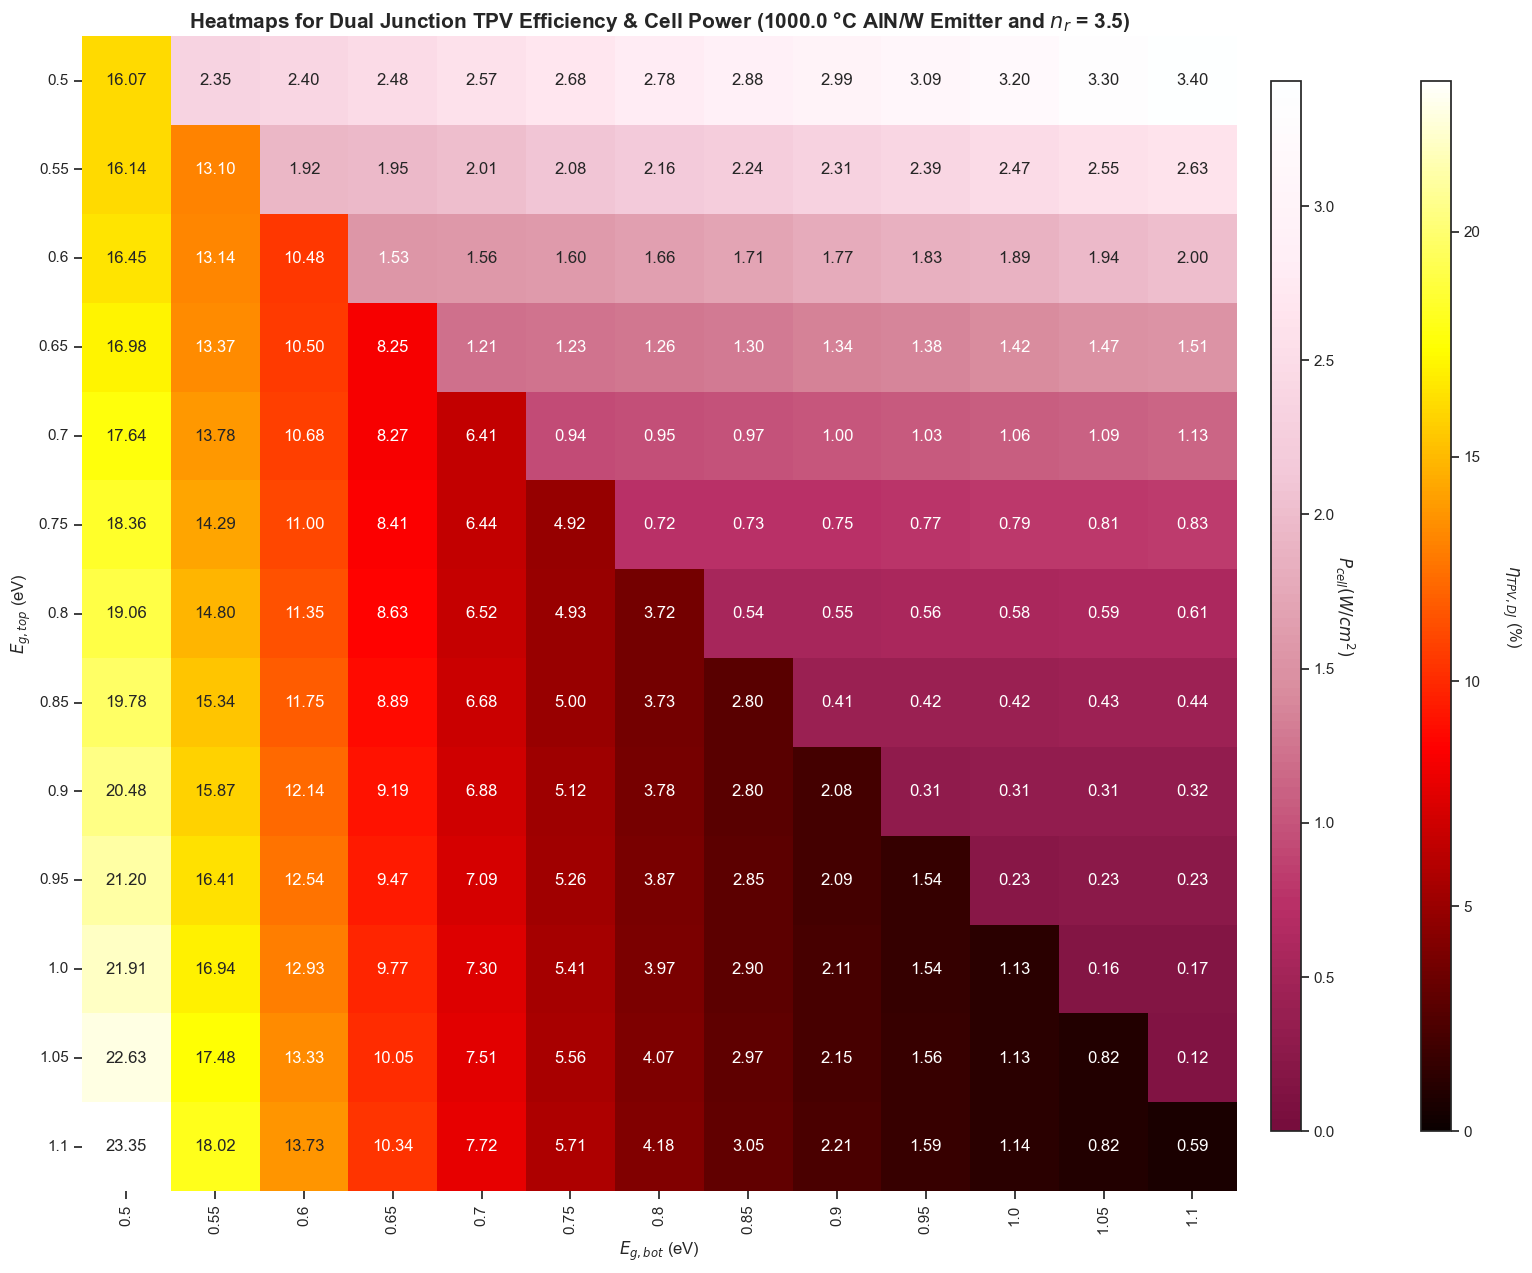

In [379]:
"""
Section 4: Creating the Heatmap 
"""

"""
heat_map() is the function that creates the heatmaps. 
see more @ https://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap



heatmap(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, 
        #square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)

"""

import seaborn as sns 
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap

newcolors = plt.get_cmap('PiYG', 256)(np.linspace(0, .48, 256))

for i in range(0,len(newcolors)):
    newcolors[i,0] = min(.027+newcolors[i,0]**1.4,1)
    newcolors[i,1] = min(.046+newcolors[i,1]**.9,1)
    newcolors[i,2] = min(.057+newcolors[i,2]**1.5,1)
    
newcmp = ListedColormap(newcolors) #updated colormap with 'newcolors' and this is a specific colormap, not a string defining the name of the cmap, so don't put quotes 



#actual plotting 


sns.set_theme(style = 'ticks')            #by default it has its own ticks unless you specify what kind of background you want 
fig, ax = plt.subplots(figsize = (15,15)) #I only need one ax because both heatmaps are going on the same ax


"""
To create this specific heatmap, I needed to do the following

1) Take the transpose of the P_cell_grid, so that way all of the values get repositioned to the upper right triangle/upper right corner

2) I needed to mask all the empty squares in the P_cell_grid transpose and the efficiency_grid. 

3) Plot both of them on the same ax(i.e. same plot) 

to better understand the mask, read it inside out

mask = np.triu(np.ones_like(efficiency_grid, dtype = bool), k = 1)
    - np.ones_like(efficiency_grid, dtype = bool) --> creates an array of ones that has the same dimensions as efficiency grid, but the data-type of each entry is a boolean.
    - booleans are 1's and 0's.
    - 1's --> True, 0 --> false 
    - So np.ones_like(efficiency_grid, dtype = bool) ends up creating an array of 'True' values 
    np.triu(A , k = B) will zero out everything from the k = B row and onward of your A-array. So now the array is full of true-false values, and this mask gets fed to the function

mask = np.tril(np.ones_like(P_cell_grid.T, dtype = bool), k = 0)

this all gets plotted onto ax, fig is the canvas 

"""

#Testing to see if these match up 
o = 0                                #o is the index of the emitter type, see above 
k = 0                                #k is the index of the specific temperature in T_emitter that I want to call 
b = 0                                #defining b to be the index of the n_r value in n_r_array 

"""
indices for the emitters are as follows:

    - 0 --> AlN/W 
    - 1 --> Yb2O3/W
    - 2 --> MgO/W
    - 3 --> Y2O3/W 
    - 4 --> BeO/W    
    - 5 --> ZrO2/W  
    - 6 --> SiO2/W
    - 7 --> TiO2/W  
    - 8 --> SiN/W  
    - 9 --> SiC/W 
    - 10 --> a-C/W 
    - 11 --> TiN/W 
    - 12 --> Si/W
    
T_emitter = np.array([1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400])
"""
efficiency_grid = efficiency_ALLTEMP[o, k, b]
P_cell_grid = P_cell_ALLTEMP[o, k, b]
coating_grid = coating_ALLTEMP[o, k, b] 

#######################################

#sns.heatmap(coating_grid, vmin = 0, vmax = np.max(coating_grid), cmap = 'hot', xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = True, mask = np.triu(np.ones_like(coating_grid, dtype = bool), k = 1), fmt = '.2f', ax = ax, cbar = False, square = True)

sns.heatmap(efficiency_grid, vmin = 0, vmax = np.max(efficiency_grid), cmap = 'hot', xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = True, mask = np.triu(np.ones_like(efficiency_grid, dtype = bool), k = 1), fmt = '.2f', ax = ax, cbar = False, square = True)


sns.heatmap(P_cell_grid.T, vmin = 0, vmax = np.max(P_cell_grid.T), cmap = newcmp, xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = True, mask = np.tril(np.ones_like(P_cell_grid.T, dtype = bool), k = 0) , fmt = '.2f', ax = ax, cbar = False, square = True)
                    #plots the heatmap on its own ticks


# Colorbar for P_cell
sm_pcell = ScalarMappable(cmap = newcmp, norm=Normalize(vmin=0, vmax=np.max(P_cell_grid.T))) #basically defines the input of the colorbar. 
cbar_ax1 = fig.add_axes([0.92, 0.15, 0.02, 0.7])                                             #position of the colorbar [left, bottom, width, height] in figure coords
P_cell_CBAR = fig.colorbar(sm_pcell, cax=cbar_ax1)                                           #plotting the colorbar onto the figure using the input, sm_pcell, and the location, cbar_ax1 
P_cell_CBAR.set_label(r'$P_{cell} (W/cm^{2})$', rotation = 270, labelpad = 15)               #labeling the color bar 

# Colorbar for efficiency
#sm_eff = ScalarMappable(cmap='hot', norm=Normalize(vmin=0, vmax=np.max(coating_grid)))
sm_eff = ScalarMappable(cmap='hot', norm=Normalize(vmin=0, vmax=np.max(efficiency_grid)))
cbar_ax2 = fig.add_axes([1.02, 0.15, 0.02, 0.7])  
eta_CBAR = fig.colorbar(sm_eff, cax=cbar_ax2)
eta_CBAR.set_label(r'$\eta_{TPV, DJ}$ (%)', rotation = 270, labelpad = 30) 


ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.set_yticklabels(ax.get_yticklabels(), rotation = 0)

ax.set_ylabel(r'$E_{g, top}$ (eV)') 
ax.set_xlabel(r'$E_{g, bot}$ (eV)') 


ax.set_title(rf'Heatmaps for Dual Junction TPV Efficiency & Cell Power ({np.round(T_emitter[k]-273.15,0)} °C {emitter_names[o]} Emitter and $n_{{r}}$ = {np.round(n_r_array[b], 2)})', fontsize = 15, fontweight = 'bold')



plt.show()


<>:102: SyntaxWarning: invalid escape sequence '\D'
<>:102: SyntaxWarning: invalid escape sequence '\D'
C:\Users\bryan\AppData\Local\Temp\ipykernel_27124\850437465.py:102: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(n_r_array, V_oc_TANDEM_vals_NOAPP.squeeze(), label = 'Full EQN & Simple $\Delta J_{L}$')
C:\Users\bryan\AppData\Local\Temp\ipykernel_27124\2709178558.py:561: RuntimeWarning: invalid value encountered in log
  return (kb_eV * T_c) * np.log(numerator / denominator)[..., 0]   #(N, 1000)
C:\Users\bryan\AppData\Local\Temp\ipykernel_27124\2709178558.py:489: RuntimeWarning: invalid value encountered in log
  return (kb_eV) * (T_c) * np.log(numerator/denominator)[..., 0] #(N, 1000) result, i.e. 1000 Vocs, one for each structure, at each value of n_r


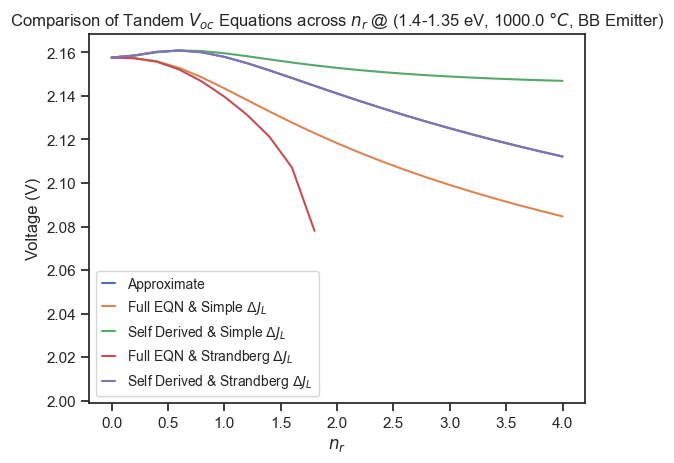

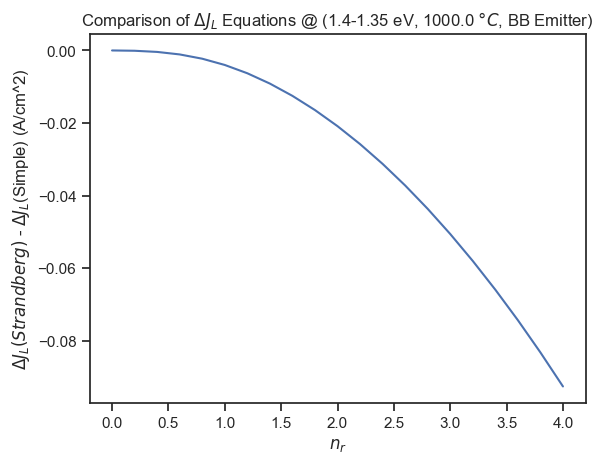

In [316]:
"Comparing Full & Approximate Equations --09-21-2026--" 


"We first need to obtain J_L & J_0 for the top and bottom rows" 

"1) Define bandgap pair and range of n_r values"
Eg_Pair = np.array([1.40, 1.35]) #both in [eV] 

n_r_array = np.arange(0, 4.2, 0.2) #n_r --> 0 to 4.0 in step sizes of 0.5; constant refractive index which might also describe the degree of radiative coupling

T_emitter = np.array([1000]) + 273.15 
T_c = 300                             #300 Kelvin 

#This line only applies if you're looking at a BB emitter. Otherwise, just keep wl_array as it's defined in section #1"
wl_array = wl_array_BB #(350 nm, 14000 nm) 

"2) Calculate J_0_TOP and J_0_BOT for your given Eg_Pair"

"Step 2.1) Pick a top-cell bandgap, which defines what wavelength range the bottom cell bandgaps see" 
Eg_TOP = np.max(Eg_Pair)                                 #Value of the Top-Cell Bandgap [eV] -- Scalar 
Eg_BOT = np.min(Eg_Pair)                                 #Value of the Bottom-Cell Bandgap [eV] -- Scalar 

lam_Eg_TOP = lam_Bandgap(Eg_TOP)                         #Corresponding wavelength of Eg_TOP in [m] --> scalar 
lam_Eg_BOT = lam_Bandgap(Eg_BOT)                         #Corresponding wavelength of Eg_BOT in [m] --> scalar 

idx_Eg = np.argmin(np.abs(wl_array - lam_Eg_TOP * 1E9))  #Finds where this wavelength is within wl_array                            

lam_fine_TOP = wl_array                                  #the top cell sees the full wavelength array [nm] --> (N,) 
lam_fine_TOP_meters = lam_fine_TOP * 1E-9                #unit conversion from [m] --> [nm] (N,) 

lam_fine_BOT_meters = lam_fine_TOP_meters[idx_Eg:]       #wavelength range seen by the bottom cell


"Step 2.2)Calculate blackbody photon spectral radiance arrays"

n_B_array_DARK_TOP = n_B(lam_fine_TOP_meters, T_c) #this is just for the top cell --> (len(lam_fine_TOP), )
n_B_array_DARK_BOT = n_B(lam_fine_BOT_meters, T_c) #this is just for the bottom cell --> (len(lam_fine_BOT), )

n_B_array_LIGHT_TOP = n_B(lam_fine_TOP_meters, T_emitter) #this is just for the top cell --> (len(lam_fine_TOP), )
n_B_array_LIGHT_BOT = n_B(lam_fine_BOT_meters, T_emitter) #this is just for the bottom cell --> (len(lam_fine_BOT), )

"Step 3) Calculate J_0 values for the top and bottom cell"

integrand_J_0_TOP_vals = q * np.pi * n_B_array_DARK_TOP *  EQE(lam_fine_TOP_meters * 1E9, lam_Eg_TOP * 1E9) #calculating all of the J_0 integrands for the top cell, just one value  ( len(lam_fine_TOP),  )
integrand_J_0_BOT_vals = q * np.pi * n_B_array_DARK_BOT *  EQE(lam_fine_BOT_meters * 1E9, lam_Eg_BOT * 1E9) #calculating all of the J_0 integrands for the bottom cell --> ( len(lam_fine_BOT), )

J_0_TOP = np.atleast_1d( simpson(integrand_J_0_TOP_vals, x = lam_fine_TOP_meters) ) # (1, ); [A/m^2]; these also had to be reshaped in order for the functions to not break. See the functions themselves for details. 
J_0_BOT = np.atleast_1d( simpson(integrand_J_0_BOT_vals, x = lam_fine_BOT_meters) ) # (1, ); [A/m^2]

"Step 4) Calculate J_L values for the top and bottom cell" 

integrand_J_L_TOP_vals = q * np.pi * n_B_array_LIGHT_TOP * EQE(lam_fine_TOP_meters * 1E9, lam_Eg_TOP * 1E9) #calculating all of the J_0 integrands for the top cell, just one value  ( len(lam_fine_TOP),  )
integrand_J_L_BOT_vals = q * np.pi * n_B_array_LIGHT_BOT * EQE(lam_fine_BOT_meters * 1E9, lam_Eg_BOT * 1E9) #calculating all of the J_0 integrands for the bottom cell --> ( len(lam_fine_BOT), )

J_L_TOP = np.atleast_1d( simpson(integrand_J_L_TOP_vals, x = lam_fine_TOP_meters) ) #(1, ); [A/m^2] 
J_L_BOT = np.atleast_1d( simpson(integrand_J_L_BOT_vals, x = lam_fine_BOT_meters) ) #(1, ); [A/m^2] -- I had to reshape it this way in order for it to not break the pre-existing functions
                                                                                    # which expect J_L as (N,) where N = # of bilayer emitter structure

"Now we can begin testing equations" 

#Approximations from Strandberg Paper 
V_oc_TANDEM_vals_APP = V_oc_DJ_RC(n_r_array, T_c, J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT) #(N,1) 
V_oc_TOP_vals_APP_vals = V_oc_TOP_vals_APP(J_L_TOP, J_0_TOP, n_r_array, T_c)          #(N,1) 
V_oc_BOT_vals_APP_vals = V_oc_BOT_vals_APP(J_L_BOT, J_L_TOP, J_0_BOT, n_r_array, T_c) #(N,1) 
"add the trailing dummy axis the V2 functions expect (mirrors how delta_J_L_calc's output gets [None,:,None]'d elsewhere)" 
V_vals_TOP_trial = V_oc_TOP_vals_APP_vals[..., None]  # (N,1,1)
V_vals_BOT_trial = V_oc_BOT_vals_APP_vals[..., None]  # (N,1,1)


"POI #1: V_oc(self consistent) of the top and bottom cell using delta_J_L STRANDBERG and the APPROXIMATE V_oc VALUES of the top and bottom cells"
V_oc_TOP_sc_V2 = V_oc_TOP_selfconsistent_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT,
                                            V_vals_TOP_trial, V_vals_BOT_trial, T_c, n_r_array)  # (N,1)
V_oc_BOT_sc_V2 = V_oc_BOT_selfconsistent_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT,
                                            V_vals_TOP_trial, V_vals_BOT_trial, T_c, n_r_array)  # (N,1)


"POI #1.1: V_oc(self consistent) of the top and bottom cell using MY DEFINITION of delta_J_L"
V_oc_TOP_sc = V_oc_TOP_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r_array)
V_oc_BOT_sc = V_oc_BOT_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r_array)


"POI #2.0: V_oc of the series connected TANDEM setup using MY DEFINITION of delta_J_L"
V_oc_TANDEM_vals_NOAPP = V_oc_TANDEM_noapprox(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r_array)    #(N, 1). 1 Voc for each N_r value. 
V_oc_TANDEM_vals_SC = V_oc_TANDEM_selfconsistent(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, T_c, n_r_array) #(N, 1) SC --> Self consistent // This is the eqn that works best for me

"POI #2.1: V_oc of the series connected TANDEM setup using delta_J_L STRANDBERG" 
V_oc_TANDEM_vals_NOAPP_V2 = V_oc_TANDEM_noapprox_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT, V_vals_TOP_trial, V_vals_BOT_trial, T_c, n_r_array)   #(N, 1). 1 Voc for each N_r value. 
V_oc_TANDEM_vals_SC_V2 = V_oc_TANDEM_selfconsistent_V2(J_L_TOP, J_L_BOT, J_0_TOP, J_0_BOT,V_vals_TOP_trial, V_vals_BOT_trial, T_c, n_r_array) #(N, 1).  

"POI #3: How do the delta J_L's compare?"

delta_J_L_me = delta_J_L_calc(J_L_TOP, J_L_BOT) #Scalar value because mine doesn't have any n_r dependence
delta_J_L_STRAND = delta_J_L_STRANDBERG(J_0_TOP, J_0_BOT, V_vals_TOP_trial, V_vals_BOT_trial, n_r_array) #(N, 1, 1) 
residuals = delta_J_L_STRAND - delta_J_L_me #(N, 1, 1) 


"Plotting Code"

#Comparison of all the V_oc Tandem Equations

plt.plot(n_r_array, V_oc_TANDEM_vals_APP.squeeze(), label = 'Approximate')
plt.plot(n_r_array, V_oc_TANDEM_vals_NOAPP.squeeze(), label = 'Full EQN & Simple $\Delta J_{L}$')
plt.plot(n_r_array, V_oc_TANDEM_vals_SC.squeeze(), label = r'Self Derived & Simple $\Delta J_{L}$ ')

plt.plot(n_r_array, V_oc_TANDEM_vals_NOAPP_V2.squeeze(), label = r'Full EQN & Strandberg $\Delta J_{L}$ ')
plt.plot(n_r_array, V_oc_TANDEM_vals_SC_V2.squeeze(), label = r'Self Derived & Strandberg $\Delta J_{L}$ ')

plt.plot(n_r_array, np.ones(len(n_r_array)) * np.min(V_oc_TANDEM_vals_SC_V2.squeeze()) * 0.95, alpha = 0.01)



plt.xlabel(r'$n_{r}$')
plt.ylabel(r'Voltage (V)')
plt.title(rf'Comparison of Tandem $V_{{oc}}$ Equations across $n_{{r}}$ @ ({Eg_TOP}-{Eg_BOT} eV, {np.round(T_emitter[0] - 273.15, 2)} $\degree C$, BB Emitter)') 
plt.legend(loc = 'lower left', fontsize = 'small', handlelength = 1.0)
plt.show()

#Plotting residuals vs. n_r to see it blow up 

plt.plot(n_r_array, residuals.squeeze() * 1E-4, label = r'$\Delta J_{L}(Strandberg)$ - $\Delta J_{L}$(Simple)') 
plt.xlabel(r'$n_{r}$')
plt.ylabel(r'$\Delta J_{L}(Strandberg)$ - $\Delta J_{L}$(Simple) (A/cm^2)')
plt.title(rf'Comparison of $\Delta J_{{L}}$ Equations @ ({Eg_TOP}-{Eg_BOT} eV, {np.round(T_emitter[0] - 273.15, 2)} $\degree C$, BB Emitter)') 
plt.show()

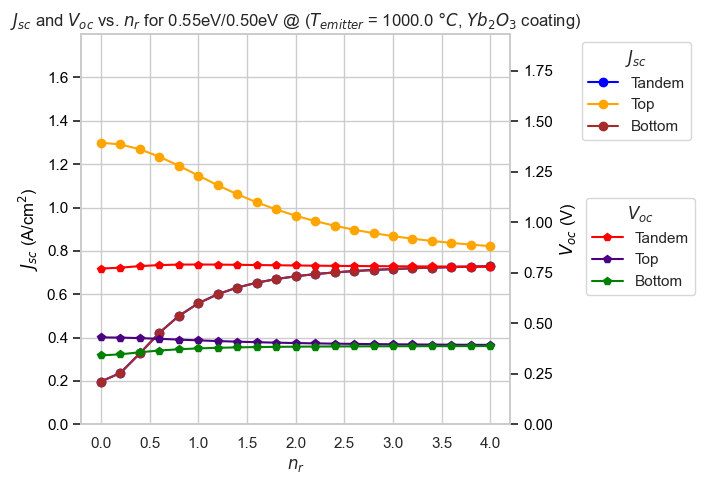

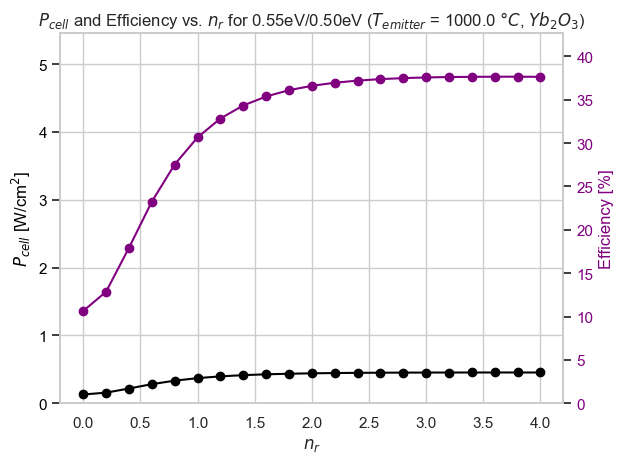

"for future Bryant, now that you have the top and bottom J-V curves respectively, make sure to plot them here too. --09/03/26-- 1:06PM and also let's go back to testing those 1.4/1.2 and 1.2/1.0 bandgaps"

In [105]:
""" Plot of J_L and Voc vs. n_r, tandem cell and individual cells only """



"""
indices for the emitters are as follows:

    - 0 --> AlN/W 
    - 1 --> Yb2O3/W
    - 2 --> MgO/W
    - 3 --> Y2O3/W 
    - 4 --> BeO/W    
    - 5 --> ZrO2/W  
    - 6 --> SiO2/W
    - 7 --> TiO2/W  
    - 8 --> SiN/W  
    - 9 --> SiC/W 
    - 10 --> a-C/W 
    - 11 --> TiN/W 
    - 12 --> Si/W

"""

#Step 1 --> Index the specific bandgap pair 
i, j = np.argmin(np.abs(Eg_Array - 0.55)), np.argmin(np.abs(Eg_Array - 0.50)) #replace the numbers with whatever bandgap pair you want 


#Indices to access 
o = 1                                  #o is the index of the emitter type, see above
k = 0                                  #k is the index of the specific temperature in T_emitter that I want to call 

"since I want to look at all of the n_r values, I don't need to use b anymore, I want to look over all n_r values and all bandgap pairs"


d_coating_optimal_all = coating_ALLTEMP[o,k, :, i, j] #now keep in mind, d_coating is ONLY filled with structures that YIELD MEP for their respective conditions(emitter type, temperature, bandgap top, bandgap bottom). 
                                                      #d_coating DOES NOT store structures that were optimized for MAXIMUM POWER. 
                                                      # Since we slice using 4/5 indices, this produces a 1D array with dimensions (N, ) 
                                                      # each value in this array is going to be a coating thickness for that respective n_r value, at this specified bandgap value


lam_Eg_TOP = lam_Bandgap(Eg_Array[i]) #Using the indices to access the corresponding wavelengths of the bandgaps 
lam_Eg_BOT = lam_Bandgap(Eg_Array[j])

idx_Eg = np.argmin(np.abs(wl_array - lam_Eg_TOP * 1E9))         #I don't think this was super necessary, I think I could've just used i here, but it's okay 



idx_opt_coat_all = np.argmin(np.abs(d_coating[:, None] - d_coating_optimal_all), axis = 0 ) # index of the Coating Thickness used (i.e. index of the respective value in d_coating)
                                                                         # (d_coating) is going to be (1000,), and it's subtracting a (N,) array. They're two different sized 1D arrays so they need to be reshaped
                                                                         # what I really want is for each value in (N,) to be substracted from all 1000 values, and then identified within that set of 1000 values
                                                                         # result of np.abs() is a (1000,N) array, where each row essentially tells you the resulting difference 
                                                                         # then specifying axis = 0, you're essentially looking at each column that contains 1000 entries each, and then identifying where the smallest
                                                                         # difference is, and then selecting the corresponding value, which is the index of the optical coating 
                                                                         # so all of that being said, the final result is going to be (N,) 



lam_fine_BOT_m = np.arange(wl_array[idx_Eg], upper_int_lim, 1) * 1E-9 #remember that it's from lam_Eg_TOP --> end of the array 

N = len(n_r_array)

J_sc_vs_nr = np.zeros(N)
V_oc_vs_nr = np.zeros(N)
P_cell_vs_nr = np.zeros(N)
efficiency_vs_nr = np.zeros(N)

"individual cell stuff is here" 

J_sc_vs_nr_TOP = np.zeros(N) 
J_sc_vs_nr_BOT = np.zeros(N) 
V_oc_vs_nr_TOP = np.zeros(N)
V_oc_vs_nr_BOT = np.zeros(N) 

for b in range(N):
    
    E_optimal_b = emissivity_ALL[o, idx_opt_coat_all[b], 0, :]       #index the emissivity of the correct structure for this n_r value 
    PC_emissivity_opt_b = PchipInterpolator(wl_array, E_optimal_b)

    emissivity_TOP_b = PC_emissivity_opt_b(lam_fine_TOP)[None, :]
    emissivity_BOT_b = PC_emissivity_opt_b(lam_fine_BOT_m * 1e9)[None, :]

    n_r_single = n_r_array[b:b+1]     # keep it as a length-1 array, not a scalar, to match the function's expected shapes


    #P_cell_DJ_RC_WCM2 returns P_cell_DJ, Power, J_vals, V_vals, J_vals_TOP, J_vals_BOT, V_vals_TOP, V_vals_BOT, delta_J_L
    P_cell_b, Power_b, J_vals_b, V_DJ_b, J_vals_TOP_b, J_vals_BOT_b, V_vals_TOP_b, V_vals_BOT_b, *_ = P_cell_DJ_RC_WCM2_vec(
        lam_fine_TOP_meters, lam_fine_BOT_m, lam_Eg_TOP, lam_Eg_BOT,
        emissivity_TOP_b, emissivity_BOT_b, T_emitter[k], T_c, n_r_single
    )

    V_oc_vs_nr[b] = V_DJ_b[0, 0, -1]           # V_oc = last point of the V sweep
    J_sc_vs_nr[b] = J_vals_b[0, 0, 0] * 1E-4   # J_sc = J at V=0, converted to A/cm^2

    P_cell_vs_nr[b] = P_cell_b[0, 0]                             # already in W/cm^2 per the function's own conversion

    P_emit_specific_b = P_emit_all[o, k, idx_opt_coat_all[b]]    # emitter power for THIS n_r's optimal structure, [W/cm^2]
    efficiency_vs_nr[b] = P_cell_vs_nr[b] / P_emit_specific_b * 100

    "individual cell stuff goes here"

    J_sc_vs_nr_TOP[b] = J_vals_TOP_b[0, 0, 0] * 1E-4 #converted to A/cm^2, J_vals_BOT_b, V_vals_TOP_b, V_vals_BOT_b
    J_sc_vs_nr_BOT[b] = J_vals_BOT_b[0, 0, 0] * 1E-4 
    V_oc_vs_nr_TOP[b] = V_vals_TOP_b[0, 0, -1]       #grabbing last value because it's supposed to be Voc
    V_oc_vs_nr_BOT[b] = V_vals_BOT_b[0, 0, -1]

    
#plotting
fig, ax1 = plt.subplots(figsize = (8,5))
ax2 = ax1.twinx()

"plotting the J_sc vs nr curves"
ax1.plot(n_r_array, J_sc_vs_nr, color='blue', marker='o', zorder = 2, label = 'Tandem')
ax1.plot(n_r_array, J_sc_vs_nr_TOP, color='orange', marker='o', zorder = 2, label = 'Top')
ax1.plot(n_r_array, J_sc_vs_nr_BOT, color='brown', marker='o', zorder = 2, label = 'Bottom')

"plotting the V_oc vs nr curves" 
ax2.plot(n_r_array, V_oc_vs_nr, color='red', marker='p', zorder = 2, label = 'Tandem')
ax2.plot(n_r_array, V_oc_vs_nr_TOP, color='indigo', marker='p', zorder = 2, label = 'Top')
ax2.plot(n_r_array, V_oc_vs_nr_BOT, color='green', marker='p', zorder = 2, label = 'Bottom')

ax1.set_xlabel(r'$n_r$')
ax1.set_ylabel(r'$J_{sc}$ (A/cm$^2$)', color='black')
ax2.set_ylabel(r'$V_{oc}$ (V)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor='black')

ax1.set_ylim(bottom=0, top = np.max(np.maximum(J_sc_vs_nr_TOP, J_sc_vs_nr_BOT)) + 0.5)
ax2.set_ylim(bottom=0, top = np.max(np.maximum(V_oc_vs_nr_TOP, V_oc_vs_nr_BOT)) + 1.5)

ax1.legend(title=r'$J_{sc}$', loc='upper left', bbox_to_anchor=(1.15, 1.0))
ax2.legend(title=r'$V_{oc}$', loc='upper right', bbox_to_anchor=(1.45, 0.6))

plt.title(rf'$J_{{sc}}$ and $V_{{oc}}$ vs. $n_r$ for {Eg_Array[i]:.2f}eV/{Eg_Array[j]:.2f}eV @ ($T_{{emitter}}$ = {np.round(T_emitter[k] - 273.15, 2)} $\degree C$, {emitter_coating_names[o]} coating)')
fig.tight_layout()
plt.grid(False)
plt.show()


#plot #2, efficiency and cell power vs. n_r 
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(n_r_array, P_cell_vs_nr, color='Black', marker='o', zorder=2)
ax2.plot(n_r_array, efficiency_vs_nr, color='purple', marker='o', zorder=2)
ax1.set_xlabel(r'$n_r$')
ax1.set_ylabel(r'$P_{cell}$ [W/cm$^2$]', color='Black')
ax2.set_ylabel(r'Efficiency [%]', color='purple')
ax1.tick_params(axis='y', labelcolor='Black')
ax2.tick_params(axis='y', labelcolor='purple')

ax1.set_ylim(bottom=0, top = np.max(P_cell_vs_nr) + 5)
ax2.set_ylim(bottom=0, top = np.max(efficiency_vs_nr) + 5)

plt.title(rf'$P_{{cell}}$ and Efficiency vs. $n_r$ for {Eg_Array[i]:.2f}eV/{Eg_Array[j]:.2f}eV ($T_{{emitter}}$ = {np.round(T_emitter[k] - 273.15, 2)} $\degree C$, {emitter_coating_names[o]})')
fig.tight_layout()
plt.grid(False)
plt.show()



"Plot of delta Eg vs. some FOM here. You'd have to do this using one fixed bandgap and then having the other one vary, and so if you do this with different bandgapas being fixed you'd see if the bandgap choice matters or not" 

"for future Bryant, now that you have the top and bottom J-V curves respectively, make sure to plot them here too. --09/03/26-- 1:06PM and also let's go back to testing those 1.4/1.2 and 1.2/1.0 bandgaps"




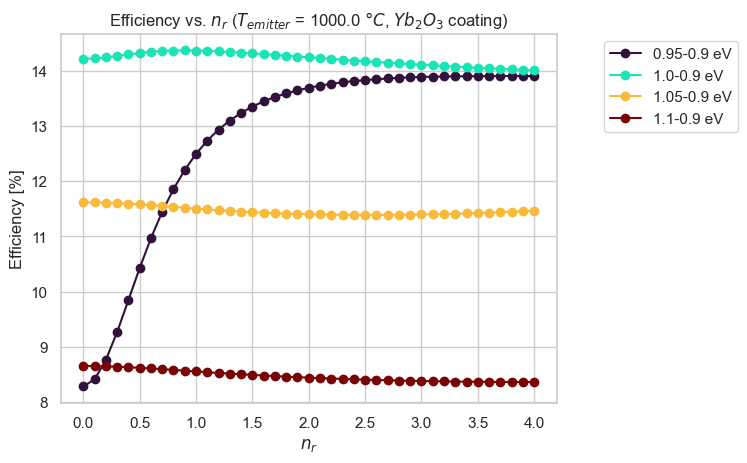

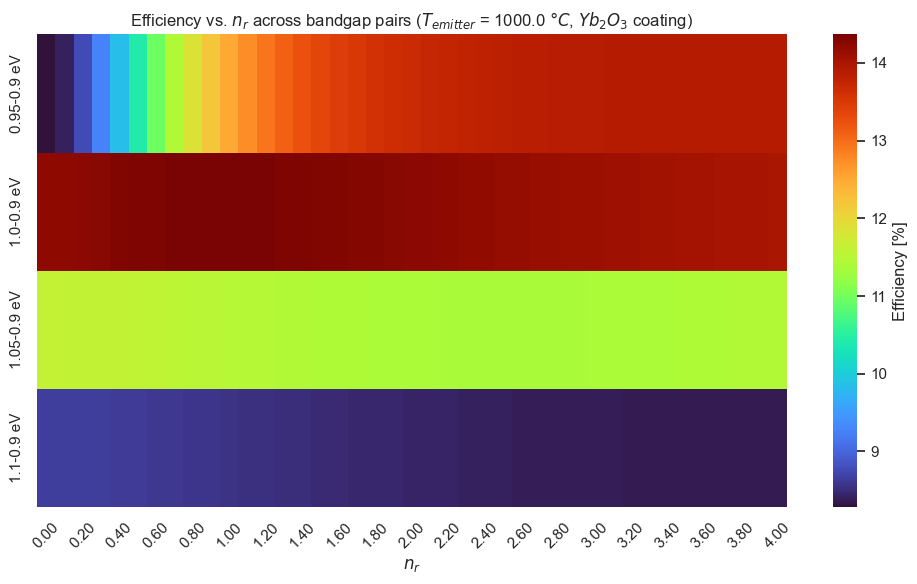

"for future Bryant, now that you have the top and bottom J-V curves respectively, make sure to plot them here too. --09/03/26-- 1:06PM and also let's go back to testing those 1.4/1.2 and 1.2/1.0 bandgaps"

In [79]:
"""
Plotting efficiency (FOM) against the n_r for multiple bandgap pairs
"""

#Indices to access 
o = 1                                  #o is the index of the emitter type, see above 
k = 0                                  #k is the index of the specific temperature in T_emitter that I want to call 


#Define your Bottom Cell here, which then determines what the top cell values can be
Eg_BOT = 0.90 #[eV]

Eg_BOT_idx = np.argmin(np.abs(Eg_Array - Eg_BOT)) #finds index of bottom cell bandgap value 
Eg_TOP_vals = Eg_Array[Eg_BOT_idx + 1:] #reshapes the array of bandgap values such that ONLY bandgaps higher than Eg_BOT are contained 


Eg_TOP_vals_idx = np.zeros(len(Eg_TOP_vals), dtype = int) #initializing an array to hold the indices of the top cell bandgap values 

for i, Eg in enumerate(Eg_TOP_vals):
    idx = np.argmin(np.abs(Eg_Array - Eg))

    Eg_TOP_vals_idx[i] = idx



eta_vs_nr_MGP = np.zeros( (len(Eg_TOP_vals),len(n_r_array)) )#MGP --> multiple bandgap pairs; basically holds all the eta vs. nr curves and there's a curve for each Top/Bottom pairing 
                                                             #there's one efficiency value per n_r value. one curve for each Eg_TOP value. 



 
for r, index_TC in enumerate(Eg_TOP_vals_idx): #index_TC --> Top Cell bandgap index 
    
    #Step 1 --> Index the specific bandgap pair 
    i, j = index_TC, Eg_BOT_idx #i is the index of the top cell bandgap and j is the index of the bottom cell bandgap 

    
    "since I want to look at all of the n_r values, I don't need to use b anymore, I want to look over all n_r values and all bandgap pairs"
    
    
    d_coating_optimal_all = coating_ALLTEMP[o,k, :, i, j] #now keep in mind, d_coating is ONLY filled with structures that YIELD MEP for their respective conditions(emitter type, temperature, bandgap top, bandgap bottom). 
                                                          #d_coating DOES NOT store structures that were optimized for MAXIMUM POWER. 
                                                          # Since we slice using 4/5 indices, this produces a 1D array with dimensions (N, ) 
                                                          # each value in this array is going to be a coating thickness for that respective n_r value, at this specified bandgap value
    
    
    lam_Eg_TOP = lam_Bandgap(Eg_Array[i]) #Using the indices to access the corresponding wavelengths of the bandgaps 
    lam_Eg_BOT = lam_Bandgap(Eg_Array[j])
    
    idx_Eg = np.argmin(np.abs(wl_array - lam_Eg_TOP * 1E9))         #I don't think this was super necessary, I think I could've just used i here, but it's okay 
    
    
    
    idx_opt_coat_all = np.argmin(np.abs(d_coating[:, None] - d_coating_optimal_all), axis = 0 ) # index of the Coating Thickness used (i.e. index of the respective value in d_coating)
                                                                             # (d_coating) is going to be (1000,), and it's subtracting a (N,) array. They're two different sized 1D arrays so they need to be reshaped
                                                                             # what I really want is for each value in (N,) to be substracted from all 1000 values, and then identified within that set of 1000 values
                                                                             # result of np.abs() is a (1000,N) array, where each row essentially tells you the resulting difference 
                                                                             # then specifying axis = 0, you're essentially looking at each column that contains 1000 entries each, and then identifying where the smallest
                                                                             # difference is, and then selecting the corresponding value, which is the index of the optical coating 
                                                                             # so all of that being said, the final result is going to be (N,) 
    
    
    
    lam_fine_BOT_m = np.arange(wl_array[idx_Eg], upper_int_lim, 1) * 1E-9 #remember that it's from lam_Eg_TOP --> end of the array 
    
    N = len(n_r_array)
    
    J_sc_vs_nr = np.zeros(N)
    V_oc_vs_nr = np.zeros(N)
    P_cell_vs_nr = np.zeros(N)
    efficiency_vs_nr = np.zeros(N)
    
    "individual cell stuff is here" 
    
    J_sc_vs_nr_TOP = np.zeros(N) 
    J_sc_vs_nr_BOT = np.zeros(N) 
    V_oc_vs_nr_TOP = np.zeros(N)
    V_oc_vs_nr_BOT = np.zeros(N) 
    
    for b in range(N):
        
        E_optimal_b = emissivity_ALL[o, idx_opt_coat_all[b], 0, :]       #index the emissivity of the correct structure for this n_r value 
        PC_emissivity_opt_b = PchipInterpolator(wl_array, E_optimal_b)
    
        emissivity_TOP_b = PC_emissivity_opt_b(lam_fine_TOP)[None, :]
        emissivity_BOT_b = PC_emissivity_opt_b(lam_fine_BOT_m * 1e9)[None, :]
    
        n_r_single = n_r_array[b:b+1]     # keep it as a length-1 array, not a scalar, to match the function's expected shapes
    
    
        #P_cell_DJ_RC_WCM2 returns P_cell_DJ, Power, J_vals, V_vals, J_vals_TOP, J_vals_BOT, V_vals_TOP, V_vals_BOT, delta_J_L
        P_cell_b, Power_b, J_vals_b, V_DJ_b, J_vals_TOP_b, J_vals_BOT_b, V_vals_TOP_b, V_vals_BOT_b, *_ = P_cell_DJ_RC_WCM2_vec(
            lam_fine_TOP_meters, lam_fine_BOT_m, lam_Eg_TOP, lam_Eg_BOT,
            emissivity_TOP_b, emissivity_BOT_b, T_emitter[k], T_c, n_r_single
        )
    
        V_oc_vs_nr[b] = V_DJ_b[0, 0, -1]           # V_oc = last point of the V sweep
        J_sc_vs_nr[b] = J_vals_b[0, 0, 0] * 1E-4   # J_sc = J at V=0, converted to A/cm^2
    
        P_cell_vs_nr[b] = P_cell_b[0, 0]                             # already in W/cm^2 per the function's own conversion
    
        P_emit_specific_b = P_emit_all[o, k, idx_opt_coat_all[b]]    # emitter power for THIS n_r's optimal structure, [W/cm^2]
        efficiency_vs_nr[b] = P_cell_vs_nr[b] / P_emit_specific_b * 100
    
        "individual cell stuff goes here"
    
        J_sc_vs_nr_TOP[b] = J_vals_TOP_b[0, 0, 0] * 1E-4 #converted to A/cm^2, J_vals_BOT_b, V_vals_TOP_b, V_vals_BOT_b
        J_sc_vs_nr_BOT[b] = J_vals_BOT_b[0, 0, 0] * 1E-4 
        V_oc_vs_nr_TOP[b] = V_vals_TOP_b[0, 0, -1]       #grabbing last value because it's supposed to be Voc
        V_oc_vs_nr_BOT[b] = V_vals_BOT_b[0, 0, -1]

    eta_vs_nr_MGP[r] = efficiency_vs_nr


#Plotting all of the curves 

cmap = plt.cm.turbo
colors = cmap(np.linspace(0, 1, len(eta_vs_nr_MGP)))

for i, curve in enumerate(eta_vs_nr_MGP):
    plt.plot(n_r_array, curve, label = rf'{np.round(Eg_TOP_vals[i], 3)}-{Eg_BOT} eV', marker = 'o', color = colors[i])

plt.xlabel(r'$n_r$')
plt.ylabel(r'Efficiency [%]')
#plt.ylim(bottom=0, top = np.max(eta_vs_nr_MGP) + 5)
plt.title(rf'Efficiency vs. $n_r$ ($T_{{emitter}}$ = {np.round(T_emitter[k] - 273.15, 2)} $\degree C$, {emitter_coating_names[o]} coating)')
fig.tight_layout()
plt.grid(True)
plt.legend(bbox_to_anchor = (1.08, 1.00), loc = 'upper left')
plt.show()


# Build labels directly from your existing variables
pair_labels = [rf'{np.round(Eg_top, 3)}-{Eg_BOT} eV' for Eg_top in Eg_TOP_vals]
nr_labels = [f'{val:.2f}' for val in n_r_array]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    eta_vs_nr_MGP,
    xticklabels=nr_labels,
    yticklabels=pair_labels,
    cmap='turbo',
    cbar_kws={'label': 'Efficiency [%]'},
    ax=ax
)

ax.set_xlabel(r'$n_r$')
ax.set_title(rf'Efficiency vs. $n_r$ across bandgap pairs ($T_{{emitter}}$ = {np.round(T_emitter[k] - 273.15, 2)} $\degree C$, {emitter_coating_names[o]} coating)')

# Thin out x-tick labels if n_r_array is dense (avoids a wall of numbers)
step = max(1, len(n_r_array) // 15)
ax.set_xticks(ax.get_xticks()[::step])
ax.set_xticklabels(nr_labels[::step], rotation=45)

fig.tight_layout()
plt.show()

"for future Bryant, now that you have the top and bottom J-V curves respectively, make sure to plot them here too. --09/03/26-- 1:06PM and also let's go back to testing those 1.4/1.2 and 1.2/1.0 bandgaps"


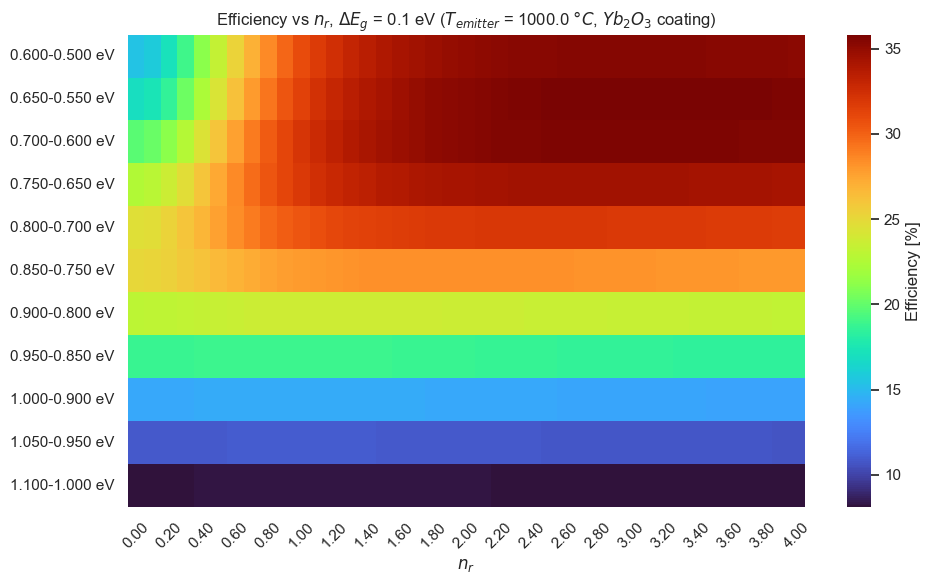

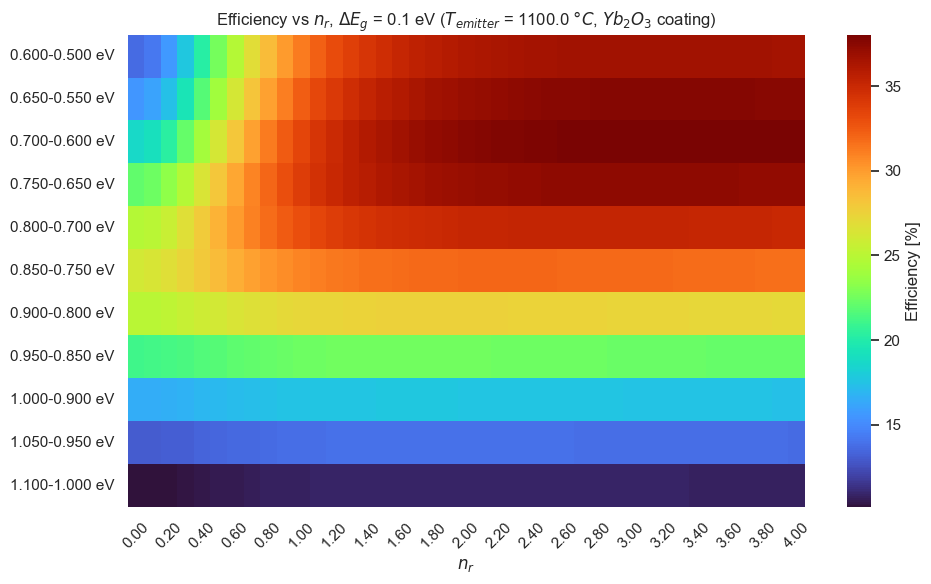

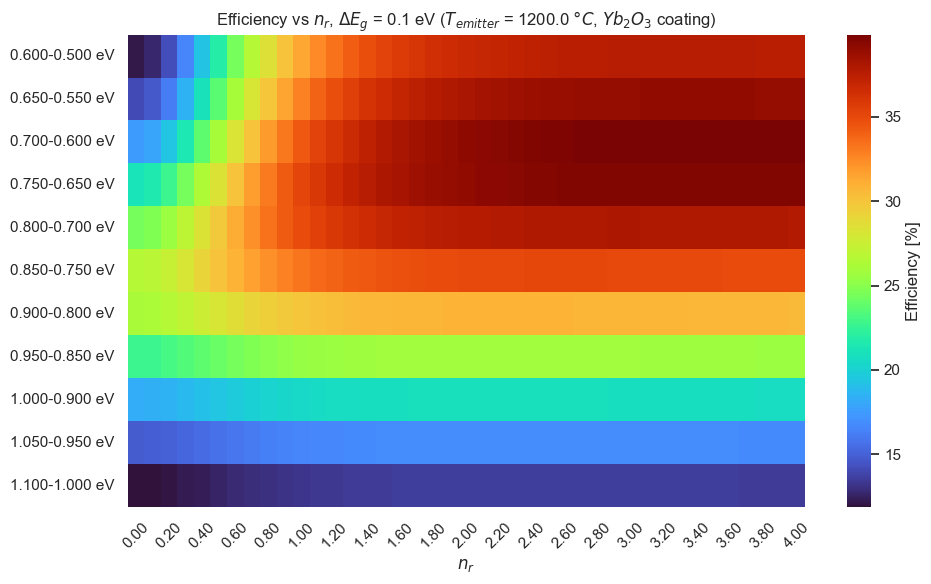

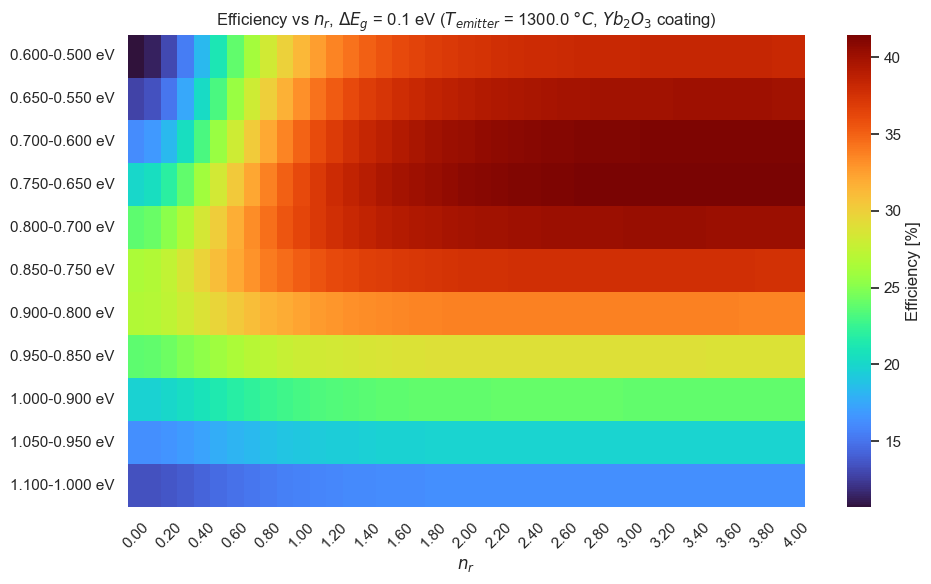

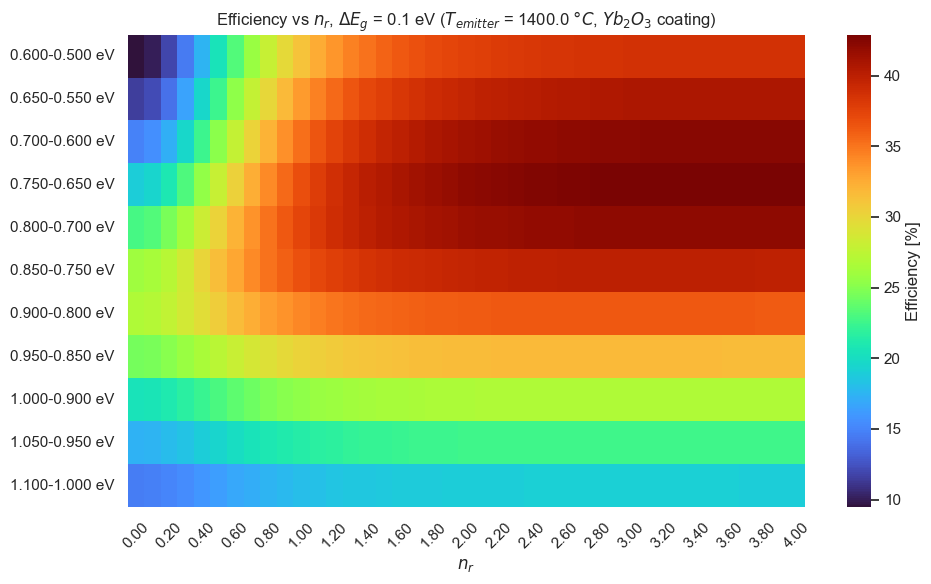

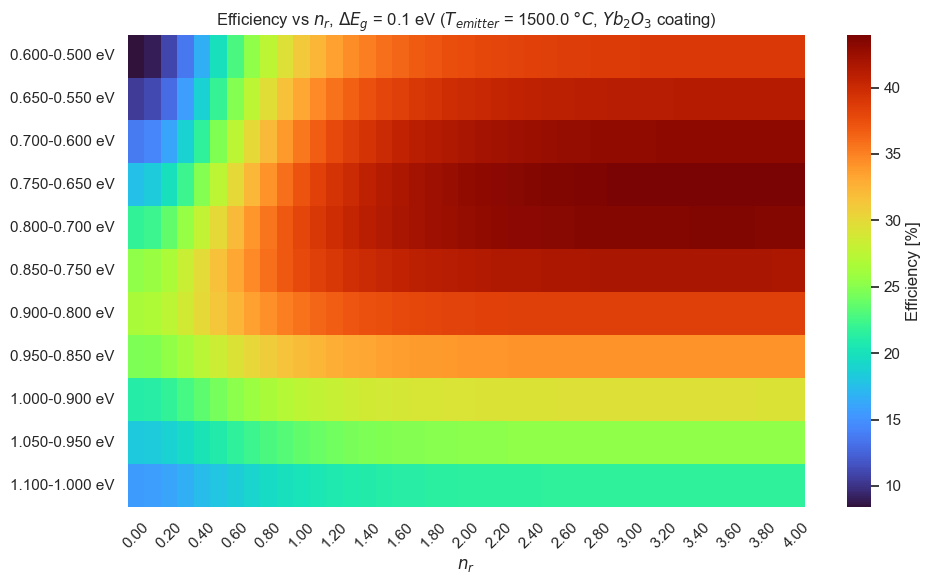

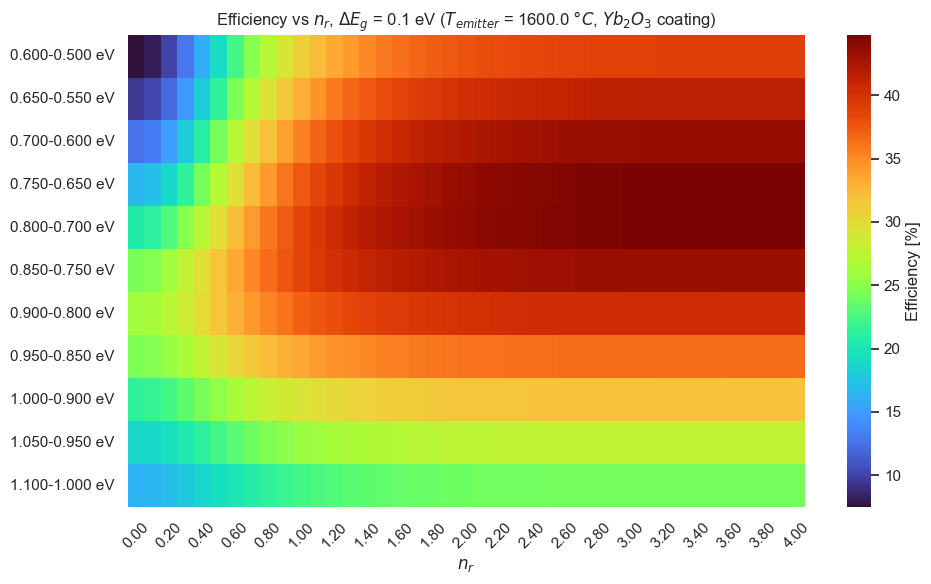

In [98]:
"Heat maps for specific Delta Eg"


def compute_eta_vs_nr_for_pair(i, j, n_r_array):
    """Efficiency vs n_r for one (Eg_TOP_idx=i, Eg_BOT_idx=j) pair."""
    d_coating_optimal_all = coating_ALLTEMP[o, k, :, i, j]

    lam_Eg_TOP = lam_Bandgap(Eg_Array[i])
    lam_Eg_BOT = lam_Bandgap(Eg_Array[j])

    idx_Eg = np.argmin(np.abs(wl_array - lam_Eg_TOP * 1e9))
    idx_opt_coat_all = np.argmin(np.abs(d_coating[:, None] - d_coating_optimal_all), axis=0)

    lam_fine_BOT_m = np.arange(wl_array[idx_Eg], upper_int_lim, 1) * 1e-9

    N = len(n_r_array)
    efficiency_vs_nr = np.zeros(N)

    for b in range(N):
        E_optimal_b = emissivity_ALL[o, idx_opt_coat_all[b], 0, :]
        PC_emissivity_opt_b = PchipInterpolator(wl_array, E_optimal_b)

        emissivity_TOP_b = PC_emissivity_opt_b(lam_fine_TOP)[None, :]
        emissivity_BOT_b = PC_emissivity_opt_b(lam_fine_BOT_m * 1e9)[None, :]

        n_r_single = n_r_array[b:b+1]

        P_cell_b, *_ = P_cell_DJ_RC_WCM2_vec(
            lam_fine_TOP_meters, lam_fine_BOT_m, lam_Eg_TOP, lam_Eg_BOT,
            emissivity_TOP_b, emissivity_BOT_b, T_emitter[k], T_c, n_r_single
        )

        P_emit_specific_b = P_emit_all[o, k, idx_opt_coat_all[b]]
        efficiency_vs_nr[b] = P_cell_b[0, 0] / P_emit_specific_b * 100

    return efficiency_vs_nr


def find_pairs_for_delta(delta_Eg, Eg_Array, tol=None):
    """
    Returns (i, j, Eg_TOP, Eg_BOT) for every Eg_BOT in Eg_Array where
    some Eg_TOP in Eg_Array satisfies Eg_TOP - Eg_BOT ≈ delta_Eg.
    """
    step = np.mean(np.diff(Eg_Array))
    if tol is None:
        tol = step / 2   # accept nearest grid point within half a step

    pairs = []
    for j, Eg_bot in enumerate(Eg_Array):
        i = np.argmin(np.abs(Eg_Array - (Eg_bot + delta_Eg)))
        actual_delta = Eg_Array[i] - Eg_bot
        if i > j and abs(actual_delta - delta_Eg) <= tol:
            pairs.append((i, j, Eg_Array[i], Eg_bot))
    return pairs



"Define the delta_Eg_target here!"
delta_Eg_target = 0.10  # eV

#Indices to access 
o = 1                                  #o is the index of the emitter type, see above 
k = 6                                  #k is the index of the specific temperature in T_emitter that I want to call, but I just edited it now to be the max index so I can plot all at once
                                       #9/16/26 4:51 PM

loop_over = np.arange(0, k + 1, 1) 


for k in loop_over:
    
    pairs = find_pairs_for_delta(delta_Eg_target, Eg_Array)
    
    eta_vs_nr_deltaEg = np.zeros((len(pairs), len(n_r_array)))
    for r, (i, j, Eg_top, Eg_bot) in enumerate(pairs):
        eta_vs_nr_deltaEg[r] = compute_eta_vs_nr_for_pair(i, j, n_r_array)
    
    pair_labels = [rf'{Eg_top:.3f}-{Eg_bot:.3f} eV' for (_, _, Eg_top, Eg_bot) in pairs]
    nr_labels = [f'{val:.2f}' for val in n_r_array]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(eta_vs_nr_deltaEg, xticklabels=nr_labels, yticklabels=pair_labels,
                cmap='turbo', cbar_kws={'label': 'Efficiency [%]'}, ax=ax)
    ax.set_xlabel(r'$n_r$')
    ax.set_title(rf'Efficiency vs $n_r$, $\Delta E_g$ = {delta_Eg_target} eV ($T_{{emitter}}$ = {np.round(T_emitter[k] - 273.15, 2)} $\degree C$, {emitter_coating_names[o]} coating)')
    
    step = max(1, len(n_r_array) // 15)
    ax.set_xticks(ax.get_xticks()[::step])
    ax.set_xticklabels(nr_labels[::step], rotation=45) 
    fig.tight_layout()
    plt.show()